# Full 3D Rossegger-style Green-function solver for the sPHENIX TPC

This notebook develops a **three-dimensional spectral Green-function solver** for the space-charge perturbation field in a bisected coaxial TPC cavity.

It calculates

$$
\delta\mathbf E(r,\phi,z)
=
\left(
E_r,\,
E_\phi,\,
E_z
\right)
$$

for an arbitrary discretized charge density

$$
\rho(r,\phi,z).
$$

The electrostatic boundary conditions are those of a grounded perturbation cavity:

$$
\delta\Phi(a,\phi,z)=0,
\qquad
\delta\Phi(b,\phi,z)=0,
$$

$$
\delta\Phi(r,\phi,0)=0,
\qquad
\delta\Phi(r,\phi,L)=0,
$$

with periodicity in azimuth.

The implementation uses the full ordinary-Bessel/Fourier/sine eigenfunction expansion. It is mathematically three-dimensional and includes all three electric-field components. It is designed as a development and validation notebook with extensive visible QA.

**Important scope statement:** Rossegger derived several mathematically equivalent representations optimized separately for convergence of \(E_r\), \(E_\phi\), and \(E_z\). This notebook first implements the common complete eigenfunction representation with finite source voxels and convergence monitoring. It does not yet claim to reproduce every component-specific convergence transformation or the imaginary-order modified-Bessel representation used in one alternative form for \(E_\phi\). Those representations can be added after the common 3D implementation passes the QA suite.

### Present default operating mode

The default configuration is the physically conservative sPHENIX baseline:

$$
\rho(r,\phi,z)\propto \frac{1}{r},
\qquad
\frac{\partial\rho}{\partial\phi}=0,
\qquad
\frac{\partial\rho}{\partial z}=0.
$$

With `AXISYMMETRIC_BASELINE = True`, only the $m=0$ harmonic is evaluated.  
With `DO_PHI_QA = False`, all plots whose main purpose is to display azimuthal dependence are skipped. The full $\phi$ machinery remains available for future measured non-axisymmetric charge maps.


## Physics roadmap and expected behavior

The notebook proceeds through the following tests.

1. **Geometry and grids:** distinguish the physical field-cage boundary, source region, and observation region.
2. **Radial eigenmodes:** find the allowed \(k_{mn}\) values for each azimuthal harmonic \(m\).
3. **Mode QA:** verify radial boundary conditions and orthogonality.
4. **Charge model:** visualize \(\rho(r,\phi,z)\) and its azimuthal Fourier spectrum.
5. **3D field solution:** calculate \(E_r\), \(E_\phi\), and \(E_z\).
6. **Axisymmetric limit:** when only \(m=0\) is present, the field must be independent of \(\phi\) and \(E_\phi=0\).
7. **Non-axisymmetric test:** an \(m=1\) or sector modulation must generate a nonzero \(E_\phi\).
8. **Boundary QA:** the perturbation potential must vanish on the conducting boundaries.
9. **Convergence QA:** partial mode sums must approach stable values.
10. **Gauss-law QA:** the integrated flux must reproduce the enclosed source charge.
11. **Optional 3D finite-difference QA:** compare an independent Poisson solution on a coarse periodic cylindrical grid.
12. **ROOT output and readback:** save and verify the full 3D maps.

Expected symmetry:

- \(m=0\): \(E_\phi=0\), no \(\phi\) dependence.
- A cosine \(m=1\) source rotates rigidly if its phase is changed.
- For a source symmetric about \(z=L/2\), \(E_r\) and \(E_\phi\) are even under \(z\rightarrow L-z\), while \(E_z\) is odd.

In [1]:
# ============================================================
# USER CONFIGURATION
# ============================================================

# Master switches
AXISYMMETRIC_BASELINE = True
DO_PHI_QA = False
WRITE_EPHI_MAP = False
DO_QA = True
DO_MODE_QA = True
DO_CONVERGENCE_QA = True
DO_GAUSS_QA = True
DO_3D_FD_CROSSCHECK = False
WRITE_ROOT_OUTPUT = True
VERIFY_ROOT_OUTPUT = True
ROOT_BATCH_MODE = True
VERBOSE = True

# Paths
CACHE_DIRECTORY = "rossegger3d_cache"
QA_PLOT_DIRECTORY = "rossegger3d_qa"
OUTPUT_ROOT_FILE = "sphenix_rossegger3d_field.root"

# Physical conducting domain, one TPC half
R_FIELD_CAGE_INNER_CM = 20.0
R_FIELD_CAGE_OUTER_CM = 75.911
DRIFT_LENGTH_CM = 102.325

# Initial source and observation domains
R_SOURCE_MIN_CM = 20.0
R_SOURCE_MAX_CM = 75.911
R_OBSERVATION_MIN_CM = 20.0
R_OBSERVATION_MAX_CM = 75.911

# Coarse development grids
DR_SOURCE_CM = 5.0
DR_OBSERVATION_CM = 4.0
DZ_SOURCE_CM = 6.0
DZ_OBSERVATION_CM = 5.0
NPHI_SOURCE = 24
NPHI_OBSERVATION = 36

# Spectral truncation
M_PHI_MAX = 6
N_RADIAL_MODES = 20
N_LONGITUDINAL_MODES = 24


# The full solver can retain m > 0, but the present physical baseline is
# cylindrically symmetric. In this mode only m = 0 is evaluated.
M_PHI_EFFECTIVE_MAX = 0 if AXISYMMETRIC_BASELINE else M_PHI_MAX

# Numerical integration and root finding
RADIAL_QUADRATURE_ORDER = 8
ROOT_SCAN_POINTS = 30000
ROOT_BRENT_XTOL = 1.0e-12
GAUSS_QUADRATURE_ORDER = 36

# Charge model
RHO_REFERENCE_NC_PER_M3 = 20.0
RADIAL_EXPONENT_ALPHA = 1.0       # rho ~ 1/r^alpha
Z_PROFILE = "uniform"

# Non-axisymmetric demonstration terms
M1_AMPLITUDE = 0.0
M1_PHASE_RAD = 0.0
M12_AMPLITUDE = 0.0

# Overall charge scaling
K_EFF = 1.0

# QA source location
QA_SOURCE_R_CM = 49.0
QA_SOURCE_PHI_RAD = 1.1
QA_SOURCE_Z_CM = 51.0


# Rossegger component-optimized radial representation
DO_ROSSEGGER_OPTIMIZED_ER = True
USE_OPTIMIZED_ER_FOR_OUTPUT = True
OPTIMIZED_ER_RADIAL_QUADRATURE_ORDER = 12
OPTIMIZED_ER_CONVERGENCE_MODES = [4, 6, 8, 12, 16, 20, 24]

# Rossegger component-optimized axisymmetric representation
DO_ROSSEGGER_OPTIMIZED_EZ = True
USE_OPTIMIZED_EZ_FOR_OUTPUT = True
OPTIMIZED_EZ_Z_QUADRATURE_ORDER = 10
OPTIMIZED_EZ_CONVERGENCE_MODES = [4, 6, 8, 12, 16, 20]

# Finite-difference cross-check grid
FD_NR = 25
FD_NPHI = 24
FD_NZ = 29

# Physical constants
EPSILON_0 = 8.8541878128e-12
ELEMENTARY_CHARGE_C = 1.602176634e-19

## Imports

ROOT is used for persistent output and QA graphics. NumPy and SciPy provide Bessel functions, root finding, quadrature, sparse linear algebra, and array operations.

The computation uses SI units internally:

- \(r,z\): metres;
- \(\phi\): radians;
- \(\rho\): \(\mathrm{C/m^3}\);
- \(\delta\mathbf E\): \(\mathrm{V/m}\).

In [2]:
import os
import json
import math
import time
from pathlib import Path
from array import array

import numpy as np
from scipy import special, optimize, sparse
from scipy.sparse import linalg as sparse_linalg
from numpy.polynomial.legendre import leggauss

import ROOT as root
from IPython.display import display, Image

if ROOT_BATCH_MODE:
    root.gROOT.SetBatch(True)

Path(CACHE_DIRECTORY).mkdir(parents=True, exist_ok=True)
Path(QA_PLOT_DIRECTORY).mkdir(parents=True, exist_ok=True)

print("ROOT :", root.gROOT.GetVersion())
print("NumPy:", np.__version__)

Welcome to JupyROOT 6.30/06
ROOT : 6.30/06
NumPy: 1.26.4


## 1. Geometry and three-dimensional grids

The full electrostatic domain is

$$
a\le r\le b,\qquad
0\le\phi<2\pi,\qquad
0\le z\le L.
$$

The source grid may begin at the GEM/readout radius while the electrostatic domain extends inward to the physical field cage. A finite source voxel has volume

$$
\Delta V
=
\frac{1}{2}
\left(r_+^2-r_-^2\right)
\Delta\phi\,\Delta z.
$$

This is a true three-dimensional cylindrical volume. The factor \(r\) from the cylindrical Jacobian is therefore included exactly.

In [3]:
CM_TO_M = 1.0e-2

a = R_FIELD_CAGE_INNER_CM * CM_TO_M
b = R_FIELD_CAGE_OUTER_CM * CM_TO_M
L = DRIFT_LENGTH_CM * CM_TO_M

r_source_min = R_SOURCE_MIN_CM * CM_TO_M
r_source_max = R_SOURCE_MAX_CM * CM_TO_M
r_obs_min = R_OBSERVATION_MIN_CM * CM_TO_M
r_obs_max = R_OBSERVATION_MAX_CM * CM_TO_M

def make_edges(xmin, xmax, target_step):
    n = int(np.ceil((xmax - xmin) / target_step))
    return np.linspace(xmin, xmax, n + 1, dtype=np.float64)

r_src_edges = make_edges(r_source_min, r_source_max, DR_SOURCE_CM*CM_TO_M)
r_obs_edges = make_edges(r_obs_min, r_obs_max, DR_OBSERVATION_CM*CM_TO_M)
z_src_edges = make_edges(0.0, L, DZ_SOURCE_CM*CM_TO_M)
z_obs_edges = make_edges(0.0, L, DZ_OBSERVATION_CM*CM_TO_M)

phi_src_edges = np.linspace(0.0, 2*np.pi, NPHI_SOURCE + 1)
phi_obs_edges = np.linspace(0.0, 2*np.pi, NPHI_OBSERVATION + 1)

r_src = 0.5*(r_src_edges[:-1] + r_src_edges[1:])
r_obs = 0.5*(r_obs_edges[:-1] + r_obs_edges[1:])
z_src = 0.5*(z_src_edges[:-1] + z_src_edges[1:])
z_obs = 0.5*(z_obs_edges[:-1] + z_obs_edges[1:])
phi_src = 0.5*(phi_src_edges[:-1] + phi_src_edges[1:])
phi_obs = 0.5*(phi_obs_edges[:-1] + phi_obs_edges[1:])

nr_src, nphi_src, nz_src = len(r_src), len(phi_src), len(z_src)
nr_obs, nphi_obs, nz_obs = len(r_obs), len(phi_obs), len(z_obs)

radial_measure_src = 0.5*(r_src_edges[1:]**2 - r_src_edges[:-1]**2)
dphi_src = np.diff(phi_src_edges)
dz_src = np.diff(z_src_edges)

source_cell_volumes = (
    radial_measure_src[:, None, None]
    * dphi_src[None, :, None]
    * dz_src[None, None, :]
)

print(f"Electrostatic domain: r=[{100*a:.3f}, {100*b:.3f}] cm, "
      f"z=[0, {100*L:.3f}] cm")
print("Source grid:", source_cell_volumes.shape,
      "voxels =", source_cell_volumes.size)
print("Observation grid:",
      (nr_obs, nphi_obs, nz_obs),
      "points =", nr_obs*nphi_obs*nz_obs)

Electrostatic domain: r=[20.000, 75.911] cm, z=[0, 102.325] cm
Source grid: (12, 24, 18) voxels = 5184
Observation grid: (14, 36, 21) points = 10584


## 2. Full cylindrical eigenfunctions

Separation of variables gives real basis functions

$$
\Psi^{(c)}_{mnl}(r,\phi,z)
=
R_{mn}(r)\cos(m\phi)\sin(q_l z),
$$

$$
\Psi^{(s)}_{mnl}(r,\phi,z)
=
R_{mn}(r)\sin(m\phi)\sin(q_l z),
$$

with

$$
q_l=\frac{l\pi}{L},\qquad l=1,2,\ldots
$$

and radial basis

$$
R_{mn}(r)
=
J_m(k_{mn}r)Y_m(k_{mn}a)
-
Y_m(k_{mn}r)J_m(k_{mn}a).
$$

This automatically vanishes at \(r=a\). The allowed radial eigenvalues satisfy

$$
R_{mn}(b)=0.
$$

The Laplacian eigenvalue is

$$
\lambda_{mnl}=k_{mn}^2+q_l^2.
$$

Expected QA:

- \(R_{mn}(a)\approx0\);
- \(R_{mn}(b)\approx0\);
- different radial modes are orthogonal with weight \(r\).

In [4]:
def radial_boundary_function(k, m):
    return (
        special.jv(m, k*b)*special.yv(m, k*a)
        - special.yv(m, k*b)*special.jv(m, k*a)
    )

def radial_basis(k, m, r):
    r = np.asarray(r)
    return (
        special.jv(m, k*r)*special.yv(m, k*a)
        - special.yv(m, k*r)*special.jv(m, k*a)
    )

def radial_basis_derivative(k, m, r):
    r = np.asarray(r)
    return k*(
        special.jvp(m, k*r, 1)*special.yv(m, k*a)
        - special.yvp(m, k*r, 1)*special.jv(m, k*a)
    )

def find_radial_roots(m, n_roots):
    spacing = np.pi/(b-a)
    kmax = (n_roots + m/2 + 10)*spacing
    x = np.linspace(max(1e-7, 1e-5*spacing), kmax, ROOT_SCAN_POINTS)
    y = radial_boundary_function(x, m)

    roots = []
    for i in range(len(x)-1):
        if not (np.isfinite(y[i]) and np.isfinite(y[i+1])):
            continue
        if y[i]*y[i+1] < 0:
            r = optimize.brentq(
                lambda kk: radial_boundary_function(kk, m),
                x[i], x[i+1], xtol=ROOT_BRENT_XTOL
            )
            if not roots or abs(r-roots[-1]) > 1e-8*spacing:
                roots.append(r)
                if len(roots) == n_roots:
                    return np.asarray(roots)
    raise RuntimeError(f"Only found {len(roots)} roots for m={m}")

k_modes = {}
for m in range(M_PHI_EFFECTIVE_MAX+1):
    cache = Path(CACHE_DIRECTORY)/f"kroots_m{m}_N{N_RADIAL_MODES}.npz"
    if cache.exists():
        k_modes[m] = np.load(cache)["k"]
    else:
        t0 = time.time()
        k_modes[m] = find_radial_roots(m, N_RADIAL_MODES)
        np.savez_compressed(cache, k=k_modes[m])
        print(f"m={m}: roots found in {time.time()-t0:.2f} s")

q_modes = np.arange(1, N_LONGITUDINAL_MODES+1)*np.pi/L

## 3. Radial normalization and visible mode QA

The normalization factors are

$$
N^{(r)}_{mn}
=
\int_a^b r\,R_{mn}^2(r)\,dr,
$$

$$
N^{(\phi)}_m
=
\begin{cases}
2\pi,&m=0,\\
\pi,&m>0,
\end{cases}
$$

and

$$
N^{(z)}_l=\frac{L}{2}.
$$

The plots below show representative radial modes and the boundary residuals. Oscillation count should increase with radial mode number, while both ends remain pinned to zero.

In [5]:
def integrate_gauss(func, xmin, xmax, order=192):
    xg, wg = leggauss(order)
    x = 0.5*(xmax-xmin)*xg + 0.5*(xmax+xmin)
    return 0.5*(xmax-xmin)*np.sum(wg*func(x))

radial_norms = {}
for m in range(M_PHI_EFFECTIVE_MAX+1):
    radial_norms[m] = np.array([
        integrate_gauss(
            lambda rr, kk=k, mm=m: rr*radial_basis(kk, mm, rr)**2,
            a, b
        )
        for k in k_modes[m]
    ])

if DO_MODE_QA:
    for m in range(min(M_PHI_EFFECTIVE_MAX, 3)+1):
        print(
            f"m={m}: max |R(a)| = "
            f"{max(abs(radial_basis(k,m,a)) for k in k_modes[m]):.3e}, "
            f"max |R(b)| = "
            f"{max(abs(radial_basis(k,m,b)) for k in k_modes[m]):.3e}"
        )

m=0: max |R(a)| = 0.000e+00, max |R(b)| = 9.971e-15


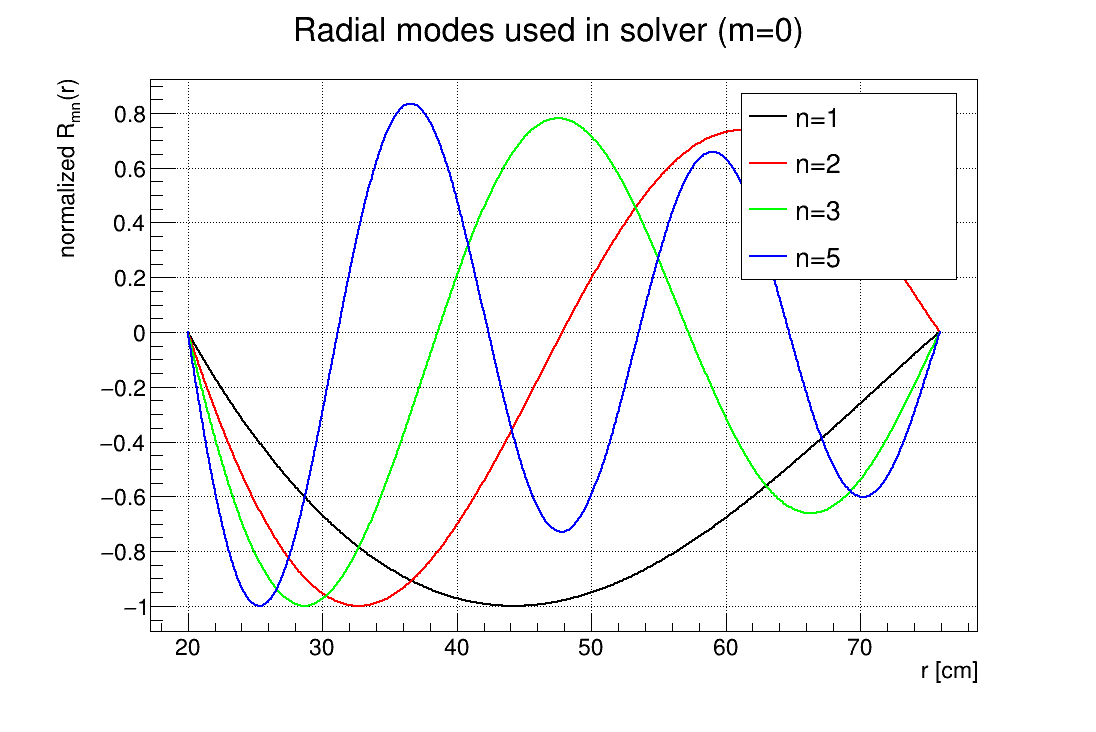

Info in <TCanvas::Print>: png file rossegger3d_qa/qa_radial_modes.png has been created


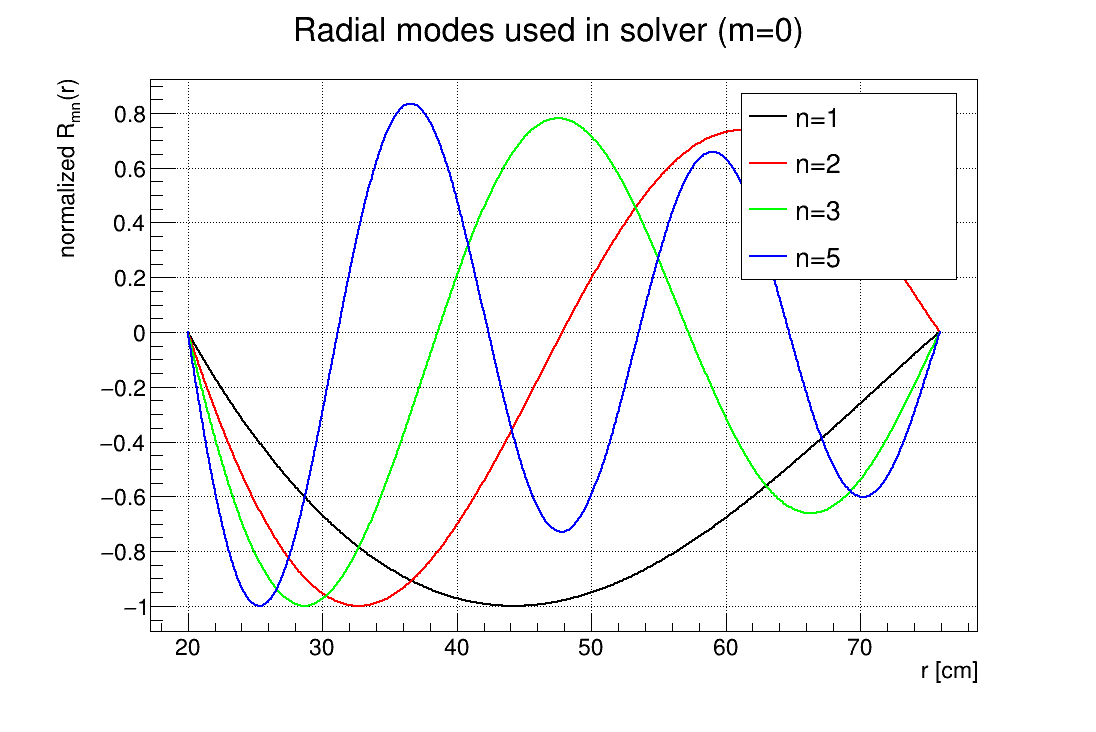

In [6]:
def graph_from_xy(x, y, name, title, xtitle, ytitle):
    xb = array("d", np.asarray(x, dtype=float).tolist())
    yb = array("d", np.asarray(y, dtype=float).tolist())
    g = root.TGraph(len(xb), xb, yb)
    g.SetName(name)
    g.SetTitle(title)
    g.GetXaxis().SetTitle(xtitle)
    g.GetYaxis().SetTitle(ytitle)
    g.SetLineWidth(2)
    g._xb, g._yb = xb, yb
    return g

qa_objects = []
qa_canvases = []

if DO_MODE_QA:
    rr = np.linspace(a, b, 500)

    # In the axisymmetric baseline, plot only the physically used m=0 modes.
    m_values_to_plot = (
        list(range(min(4, M_PHI_EFFECTIVE_MAX + 1)))
        if DO_PHI_QA
        else [0]
    )

    ncols = 2 if len(m_values_to_plot) > 1 else 1
    nrows = int(np.ceil(len(m_values_to_plot) / ncols))

    c_modes = root.TCanvas(
        "qa_radial_modes", "", 1100, 760 if nrows == 1 else 900
    )
    c_modes.Divide(ncols, nrows)

    radial_mode_multigraphs = []
    radial_mode_legends = []
    radial_mode_graphs = []

    for ipad, m in enumerate(m_values_to_plot, start=1):
        c_modes.cd(ipad)
        root.gPad.SetGrid()
        root.gPad.SetLeftMargin(0.13)
        root.gPad.SetBottomMargin(0.13)

        mg = root.TMultiGraph()
        legend = root.TLegend(0.68, 0.62, 0.88, 0.88)

        for j, n in enumerate([0, 1, 2, 4]):
            if n >= N_RADIAL_MODES:
                continue

            vals = radial_basis(k_modes[m][n], m, rr)
            vals /= np.max(np.abs(vals))

            g = graph_from_xy(
                100.0 * rr, vals,
                f"gR_m{m}_n{n}", "",
                "r [cm]", "normalized R_{mn}(r)"
            )
            g.SetLineColor(j + 1)
            g.SetLineWidth(2)

            mg.Add(g, "L")
            legend.AddEntry(g, f"n={n+1}", "l")

            qa_objects.append(g)
            radial_mode_graphs.append(g)

        mg.SetTitle(
            f"Radial modes used in solver (m={m});"
            "r [cm];normalized R_{mn}(r)"
        )
        mg.Draw("A")
        legend.Draw()

        root.gPad.Modified()
        root.gPad.Update()

        radial_mode_multigraphs.append(mg)
        radial_mode_legends.append(legend)

    c_modes.Modified()
    c_modes.Update()

    png = str(Path(QA_PLOT_DIRECTORY) / "qa_radial_modes.png")
    c_modes.SaveAs(png)
    display(Image(filename=png))

    qa_canvases.append(c_modes)

## 4. Finite 3D source voxels and Fourier projection

A source voxel spans finite intervals in \(r'\), \(\phi'\), and \(z'\). Its contribution is projected onto cosine and sine azimuthal modes.

For a piecewise-constant voxel density,

$$
S^{(c)}_{mnl}
=
\int_{\rm voxel}
\rho\,
R_{mn}(r')
\cos(m\phi')
\sin(q_l z')
\,r'\,dr'\,d\phi'\,dz',
$$

with an analogous sine coefficient.

Finite voxels regularize the point-source singularity and improve convergence near the source.

The full 3D charge model used for development is

$$
\rho(r,\phi,z)
\propto
\left(\frac{r_{\rm ref}}{r}\right)^\alpha
\left[
1+A_1\cos(\phi-\phi_1)
+A_{12}\cos(12\phi)
\right].
$$

Set `M1_AMPLITUDE = 0` and `M12_AMPLITUDE = 0` for the axisymmetric limit.

In [7]:
def build_charge_density():
    rr = r_src[:, None, None]
    pp = phi_src[None, :, None]

    radial = (r_source_min/rr)**RADIAL_EXPONENT_ALPHA
    azimuthal = (
        1.0
        + M1_AMPLITUDE*np.cos(pp-M1_PHASE_RAD)
        + M12_AMPLITUDE*np.cos(12*pp)
    )

    shape = radial*azimuthal*np.ones((1,1,nz_src))
    if np.min(shape) <= 0:
        raise ValueError("Charge modulation produced non-positive density.")

    target = RHO_REFERENCE_NC_PER_M3*1e-9
    mean_shape = np.sum(shape*source_cell_volumes)/np.sum(source_cell_volumes)
    return K_EFF*target*shape/mean_shape

rho = build_charge_density()
Q_cells = rho*source_cell_volumes
Q_total = np.sum(Q_cells)

print(f"Total charge, one side = {Q_total:.6e} C")
print(f"Positive ions          = {Q_total/ELEMENTARY_CHARGE_C:.6e}")
print(f"rho range              = [{rho.min()*1e9:.3f}, "
      f"{rho.max()*1e9:.3f}] nC/m^3")

Total charge, one side = 3.447683e-08 C
Positive ions          = 2.151874e+11
rho range              = [13.035, 42.952] nC/m^3


### Visible charge-density QA

The \(r\)-\(\phi\) slice should show:

- a smooth radial decrease for \(\alpha>0\);
- a broad dipole asymmetry from the \(m=1\) term;
- a smaller 12-fold modulation if `M12_AMPLITUDE` is nonzero.

The Fourier spectrum should peak at \(m=0\), with visible entries at the explicitly injected harmonics. Harmonics above `M_PHI_MAX` cannot influence the calculated field and should therefore be monitored.

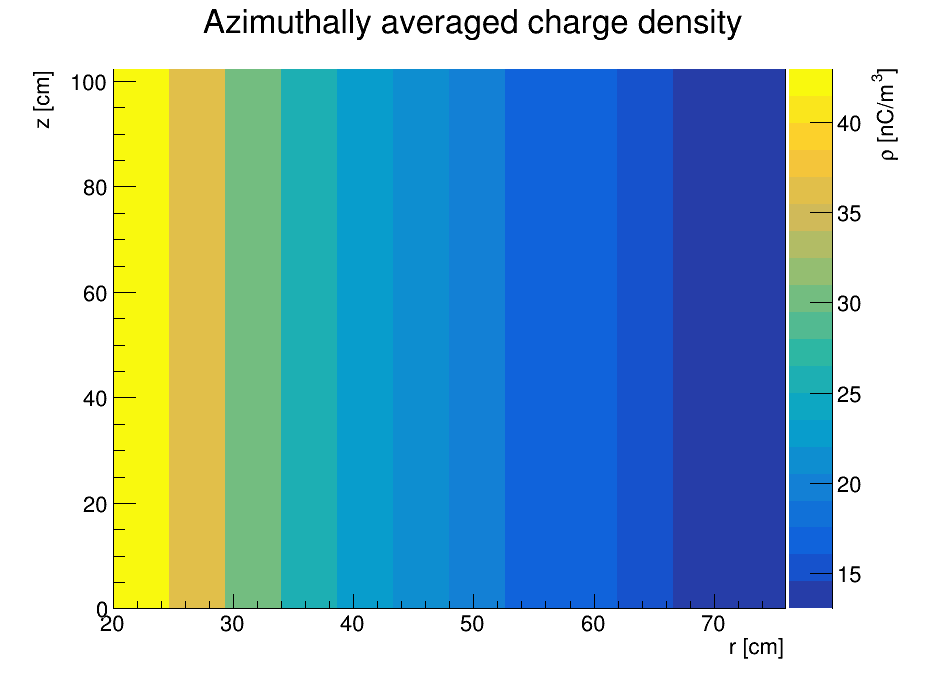

Info in <TCanvas::Print>: png file rossegger3d_qa/qa_rho_rz.png has been created


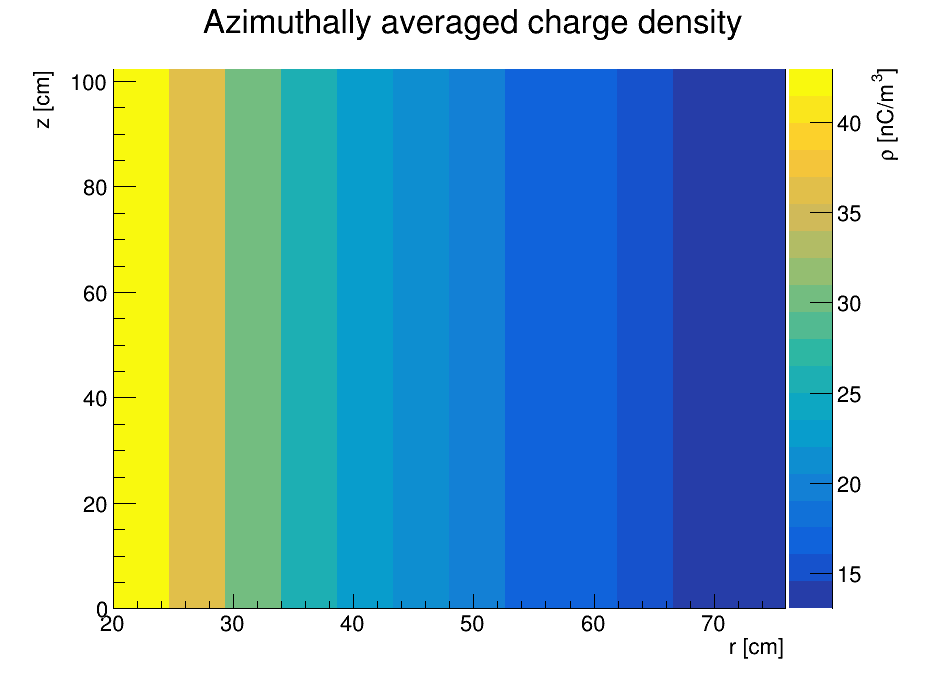

In [8]:
def make_th2(name, title, values, x_edges, y_edges, xtitle, ytitle, ztitle):
    xb = array("d", np.asarray(x_edges, dtype=float).tolist())
    yb = array("d", np.asarray(y_edges, dtype=float).tolist())
    h = root.TH2D(name, title, len(xb)-1, xb, len(yb)-1, yb)
    h.GetXaxis().SetTitle(xtitle)
    h.GetYaxis().SetTitle(ytitle)
    h.GetZaxis().SetTitle(ztitle)
    h.SetStats(False)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            h.SetBinContent(i+1, j+1, float(values[i,j]))
    return h

def draw_th2(name, h, width=950, height=720):
    c = root.TCanvas(name, "", width, height)
    c.SetRightMargin(0.17)
    c.SetLeftMargin(0.12)
    c.SetBottomMargin(0.12)
    h.Draw("COLZ")
    c.Update()
    png = str(Path(QA_PLOT_DIRECTORY)/f"{name}.png")
    c.SaveAs(png)
    display(Image(filename=png))
    qa_objects.append(h)
    qa_canvases.append(c)
    return c

if DO_QA:
    if DO_PHI_QA:
        iz = nz_src//2
        h_rphi = make_th2(
            "hRhoRPhi",
            f"Charge density at z={100*z_src[iz]:.1f} cm",
            rho[:,:,iz]*1e9,
            100*r_src_edges, phi_src_edges,
            "r [cm]", "#phi [rad]", "#rho [nC/m^{3}]"
        )
        draw_th2("qa_rho_rphi", h_rphi)

        phi_weights = np.sum(Q_cells, axis=(0,2))
        mplot = np.arange(0, min(NPHI_SOURCE//2, 16)+1)
        power = []
        for m in mplot:
            c = np.sum(phi_weights*np.cos(m*phi_src))
            s = np.sum(phi_weights*np.sin(m*phi_src))
            power.append(np.hypot(c,s)/np.sum(phi_weights))

        gpow = graph_from_xy(
            mplot, power, "gChargeFourierPower",
            "Azimuthal Fourier spectrum of source charge",
            "m", "normalized amplitude"
        )
        gpow.SetMarkerStyle(20)
        c = root.TCanvas("qa_charge_fourier", "", 900, 650)
        c.SetGrid()
        gpow.Draw("ALP")
        c.Update()
        png = str(Path(QA_PLOT_DIRECTORY)/"qa_charge_fourier.png")
        c.SaveAs(png)
        display(Image(filename=png))
        qa_objects.append(gpow)
        qa_canvases.append(c)

    # Always show the physically relevant r-z density.
    rho_rz = np.mean(rho, axis=1)
    h_rz = make_th2(
        "hRhoRZ",
        "Azimuthally averaged charge density",
        rho_rz*1e9,
        100*r_src_edges, 100*z_src_edges,
        "r [cm]", "z [cm]", "#rho [nC/m^{3}]"
    )
    draw_th2("qa_rho_rz", h_rz)

## 5. Source projections and modal coefficients

For each azimuthal order \(m\), cosine and sine source coefficients are calculated independently.

The potential coefficients are

$$
A^{(c,s)}_{mnl}
=
\frac{
S^{(c,s)}_{mnl}
}{
\epsilon_0
\lambda_{mnl}
N^{(r)}_{mn}
N^{(\phi)}_m
N^{(z)}_l
}.
$$

For \(m=0\), the sine branch is identically zero.

The field follows from

$$
E_r=-\frac{\partial\Phi}{\partial r},
\qquad
E_\phi=-\frac{1}{r}\frac{\partial\Phi}{\partial\phi},
\qquad
E_z=-\frac{\partial\Phi}{\partial z}.
$$

In [9]:
def interval_integrals_for_m(m):
    # Radial integrals per source radial cell and radial mode.
    xg, wg = leggauss(RADIAL_QUADRATURE_ORDER)
    Ir = np.zeros((nr_src, N_RADIAL_MODES))
    for ir in range(nr_src):
        lo, hi = r_src_edges[ir], r_src_edges[ir+1]
        rr = 0.5*(hi-lo)*xg + 0.5*(hi+lo)
        jac = 0.5*(hi-lo)
        vals = np.stack(
            [radial_basis(k, m, rr) for k in k_modes[m]], axis=1
        )
        Ir[ir] = jac*np.sum(wg[:,None]*rr[:,None]*vals, axis=0)

    # Exact angular integrals.
    plo = phi_src_edges[:-1,None]
    phi = phi_src_edges[1:,None]
    if m == 0:
        Ic = (phi-plo)
        Is = np.zeros_like(Ic)
    else:
        Ic = (np.sin(m*phi)-np.sin(m*plo))/m
        Is = (-np.cos(m*phi)+np.cos(m*plo))/m

    # Exact z integrals.
    zlo = z_src_edges[:-1,None]
    zhi = z_src_edges[1:,None]
    Iz = (
        np.cos(q_modes[None,:]*zlo)
        - np.cos(q_modes[None,:]*zhi)
    )/q_modes[None,:]

    return Ir, Ic[:,0], Is[:,0], Iz

modal_coeff_cos = {}
modal_coeff_sin = {}

for m in range(M_PHI_EFFECTIVE_MAX+1):
    Ir, Ic, Is, Iz = interval_integrals_for_m(m)

    Sc = np.zeros((N_RADIAL_MODES, N_LONGITUDINAL_MODES))
    Ss = np.zeros_like(Sc)

    # Density is constant inside each finite voxel.
    for ir in range(nr_src):
        for ip in range(nphi_src):
            for iz in range(nz_src):
                rho_cell = rho[ir,ip,iz]
                outer = np.outer(Ir[ir], Iz[iz])
                Sc += rho_cell*Ic[ip]*outer
                Ss += rho_cell*Is[ip]*outer

    lam = k_modes[m][:,None]**2 + q_modes[None,:]**2
    nphi_norm = 2*np.pi if m == 0 else np.pi
    denom = (
        EPSILON_0
        * lam
        * radial_norms[m][:,None]
        * nphi_norm
        * (L/2)
    )

    modal_coeff_cos[m] = Sc/denom
    modal_coeff_sin[m] = Ss/denom

print("Modal coefficients prepared for m=0..", M_PHI_EFFECTIVE_MAX)

Modal coefficients prepared for m=0.. 0


## 6. Evaluate the complete 3D electric field

For each observation point, all retained \(m,n,l\) modes are summed.

For cosine and sine branches,

$$
E_\phi
=
\frac{m}{r}
R_{mn}(r)
\left[
A^{(c)}_{mnl}\sin(m\phi)
-
A^{(s)}_{mnl}\cos(m\phi)
\right]
\sin(q_lz).
$$

This component vanishes automatically for \(m=0\).

Expected field QA:

- \(E_\phi\) is zero in an axisymmetric run;
- nonzero \(m\) charge generates structured \(E_\phi\);
- all components remain periodic in \(\phi\).

In [10]:
def evaluate_field_point(r, phi, z, m_limit=None,
                         nrad_limit=None, nzmode_limit=None,
                         return_potential=False):
    if m_limit is None:
        m_limit = M_PHI_EFFECTIVE_MAX
    if nrad_limit is None:
        nrad_limit = N_RADIAL_MODES
    if nzmode_limit is None:
        nzmode_limit = N_LONGITUDINAL_MODES

    Er = 0.0
    Ephi = 0.0
    Ez = 0.0
    Phi = 0.0

    for m in range(m_limit+1):
        k = k_modes[m][:nrad_limit]
        R = np.array([radial_basis(kk,m,r) for kk in k])
        dR = np.array([radial_basis_derivative(kk,m,r) for kk in k])
        sz = np.sin(q_modes[:nzmode_limit]*z)
        cz = np.cos(q_modes[:nzmode_limit]*z)

        Ac = modal_coeff_cos[m][:nrad_limit,:nzmode_limit]
        As = modal_coeff_sin[m][:nrad_limit,:nzmode_limit]

        cm = np.cos(m*phi)
        sm = np.sin(m*phi)

        angular_coeff = Ac*cm + As*sm
        Phi += np.sum(angular_coeff*np.outer(R,sz))
        Er += np.sum(-angular_coeff*np.outer(dR,sz))
        Ez += np.sum(
            -angular_coeff*np.outer(R,q_modes[:nzmode_limit]*cz)
        )

        if m > 0:
            phi_coeff = Ac*sm - As*cm
            Ephi += np.sum(
                (m/r)*phi_coeff*np.outer(R,sz)
            )

    if return_potential:
        return Phi, Er, Ephi, Ez
    return Er, Ephi, Ez

E_r = np.zeros((nr_obs,nphi_obs,nz_obs))
E_phi = np.zeros_like(E_r)
E_z = np.zeros_like(E_r)
Phi_grid = np.zeros_like(E_r)

t0 = time.time()
for ir, rr in enumerate(r_obs):
    for ip, pp in enumerate(phi_obs):
        for iz, zz in enumerate(z_obs):
            Phi_grid[ir,ip,iz], E_r[ir,ip,iz], E_phi[ir,ip,iz], E_z[ir,ip,iz] = (
                evaluate_field_point(rr,pp,zz,return_potential=True)
            )
print(f"3D field evaluated in {time.time()-t0:.2f} s")
print("max |Er|   =", np.max(np.abs(E_r)), "V/m")
print("max |Ephi| =", np.max(np.abs(E_phi)), "V/m")
print("max |Ez|   =", np.max(np.abs(E_z)), "V/m")

# Preserve the common Fourier-sine result before applying any
# component-optimized Rossegger replacement.
E_r_common = E_r.copy()
E_phi_common = E_phi.copy()
E_z_common = E_z.copy()


3D field evaluated in 4.42 s
max |Er|   = 897.8761880507967 V/m
max |Ephi| = 0.0 V/m
max |Ez|   = 476.40842678267853 V/m


## 6a. Rossegger component-optimized representation for \(E_z\)

The common representation above expands the longitudinal dependence in sine modes. It is complete, but Rossegger emphasizes that differentiating a complete Green-function series does not guarantee equally good numerical convergence for every field component.

For the longitudinal component, Rossegger recommends the ordinary-Bessel radial representation with the longitudinal Green function kept in closed hyperbolic form. For the axisymmetric case,

$$
G_k(z,z')
=
\frac{
\sinh(kz_<)\,
\sinh[k(L-z_>)]
}{
k\sinh(kL)
},
$$

where

$$
z_< = \min(z,z'),
\qquad
z_> = \max(z,z').
$$

The optimized longitudinal field is obtained from

$$
E_z^{\mathrm{opt}}
=
-\frac{\partial\Phi}{\partial z}.
$$

For one radial eigenmode,

$$
\frac{\partial G_k}{\partial z}
=
\begin{cases}
\dfrac{
\cosh(kz)\sinh[k(L-z')]
}{
\sinh(kL)
},
& z<z',
\\[10pt]
-\dfrac{
\sinh(kz')\cosh[k(L-z)]
}{
\sinh(kL)
},
& z>z'.
\end{cases}
$$

This is the \(m=0\) specialization of Rossegger's recommended expression for \(E_z\) from a finite POC source volume. The radial source integral is unchanged; only the longitudinal representation changes.

Expected QA:

- optimized and common \(E_z\) agree in the bulk;
- largest differences occur near source-cell edges and end boundaries;
- optimized \(E_z\) approaches a stable value as radial modes are increased.

In [11]:
# ============================================================
# Rossegger optimized Ez for the axisymmetric m=0 baseline
# ============================================================

def d_green_z_dz(k, z_obs_value, z_source_value):
    # Derivative with respect to observation z of the hyperbolic
    # longitudinal Green function.
    if z_obs_value < z_source_value:
        return (
            np.cosh(k*z_obs_value)
            * np.sinh(k*(L-z_source_value))
            / np.sinh(k*L)
        )
    if z_obs_value > z_source_value:
        return (
            -np.sinh(k*z_source_value)
            * np.cosh(k*(L-z_obs_value))
            / np.sinh(k*L)
        )
    return 0.0


def build_optimized_ez(n_radial_modes=None):
    if not AXISYMMETRIC_BASELINE:
        raise RuntimeError(
            "The current optimized Ez implementation is the m=0 "
            "axisymmetric specialization."
        )

    if n_radial_modes is None:
        n_radial_modes = N_RADIAL_MODES
    n_radial_modes = min(int(n_radial_modes), N_RADIAL_MODES)

    m = 0
    k_used = k_modes[m][:n_radial_modes]
    norm_used = radial_norms[m][:n_radial_modes]

    xg_r, wg_r = leggauss(RADIAL_QUADRATURE_ORDER)
    radial_integrals = np.zeros((nr_src, n_radial_modes))

    for ir in range(nr_src):
        rlo = r_src_edges[ir]
        rhi = r_src_edges[ir+1]
        rr = 0.5*(rhi-rlo)*xg_r + 0.5*(rhi+rlo)
        jac = 0.5*(rhi-rlo)

        modes_at_r = np.stack(
            [radial_basis(k, m, rr) for k in k_used],
            axis=1
        )
        radial_integrals[ir, :] = (
            jac
            * np.sum(
                wg_r[:, None] * rr[:, None] * modes_at_r,
                axis=0
            )
        )

    rho_rz = np.mean(rho, axis=1)

    source_radial_projection = np.einsum(
        "rz,rn->zn",
        rho_rz,
        radial_integrals
    )

    R_obs = np.stack(
        [radial_basis(k, m, r_obs) for k in k_used],
        axis=1
    )

    xg_z, wg_z = leggauss(OPTIMIZED_EZ_Z_QUADRATURE_ORDER)
    z_response = np.zeros((nz_obs, nz_src, n_radial_modes))

    for iz_obs, z_value in enumerate(z_obs):
        for iz_src in range(nz_src):
            zlo = z_src_edges[iz_src]
            zhi = z_src_edges[iz_src+1]
            zz = 0.5*(zhi-zlo)*xg_z + 0.5*(zhi+zlo)
            jac = 0.5*(zhi-zlo)

            for n, k in enumerate(k_used):
                vals = np.array([
                    d_green_z_dz(k, z_value, zp)
                    for zp in zz
                ])
                z_response[iz_obs, iz_src, n] = (
                    jac * np.sum(wg_z*vals)
                )

    Ez_rz = np.zeros((nr_obs, nz_obs))

    for iz_obs in range(nz_obs):
        modal_z_weight = np.sum(
            source_radial_projection
            * z_response[iz_obs, :, :],
            axis=0
        )

        Ez_rz[:, iz_obs] = (
            -1.0/EPSILON_0
            * np.sum(
                R_obs
                * (modal_z_weight/norm_used)[None, :],
                axis=1
            )
        )

    return np.repeat(
        Ez_rz[:, None, :],
        nphi_obs,
        axis=1
    )


if DO_ROSSEGGER_OPTIMIZED_EZ:
    t0 = time.time()
    E_z_rossegger = build_optimized_ez()
    print(
        "Rossegger optimized Ez evaluated in "
        f"{time.time()-t0:.2f} s"
    )

    Ez_difference = E_z_rossegger - E_z_common
    Ez_reference = max(
        np.max(np.abs(E_z_rossegger)),
        1.0e-30
    )

    print(
        "max |Ez(opt)-Ez(common)| =",
        np.max(np.abs(Ez_difference)),
        "V/m"
    )
    print(
        "RMS Ez difference =",
        np.sqrt(np.mean(Ez_difference**2)),
        "V/m"
    )
    print(
        "max difference / peak optimized Ez =",
        np.max(np.abs(Ez_difference))/Ez_reference
    )

    if USE_OPTIMIZED_EZ_FOR_OUTPUT:
        E_z = E_z_rossegger.copy()
        print("Production E_z replaced by Rossegger optimized result.")
    else:
        E_z = E_z_common.copy()
        print("Production E_z remains the common sine-mode result.")
else:
    E_z_rossegger = None
    Ez_difference = None
    E_z = E_z_common.copy()

Rossegger optimized Ez evaluated in 0.16 s
max |Ez(opt)-Ez(common)| = 34.537525925519674 V/m
RMS Ez difference = 9.704972980948208 V/m
max difference / peak optimized Ez = 0.07567978660885316
Production E_z replaced by Rossegger optimized result.


## 6b. Rossegger component-optimized representation for \(E_r\)

For \(E_r\), Rossegger uses the representation in which the longitudinal coordinate is expanded in sine modes while the radial Green function is kept in closed form with modified Bessel functions.

For the axisymmetric \(m=0\) case and longitudinal mode

$$
q_l=\frac{l\pi}{L},
$$

define two radial solutions,

$$
u_l(r)
=
I_0(q_lr)K_0(q_la)
-
K_0(q_lr)I_0(q_la),
$$

$$
v_l(r)
=
I_0(q_lr)K_0(q_lb)
-
K_0(q_lr)I_0(q_lb).
$$

They satisfy

$$
u_l(a)=0,
\qquad
v_l(b)=0.
$$

The radial Green function is

$$
g_l(r,r')
=
-\frac{
u_l(r_<)\,v_l(r_>)
}{
C_l
},
$$

with

$$
C_l
=
K_0(q_la)I_0(q_lb)
-
I_0(q_la)K_0(q_lb).
$$

It obeys the correct derivative jump at \(r=r'\) and the radial Dirichlet conditions at both field cages.

The optimized radial field is then

$$
E_r^{\mathrm{opt}}(r,z)
=
-\frac{2}{\epsilon_0L}
\sum_l
\sin(q_lz)
\int_a^b
r'\,dr'\,
\frac{\partial g_l(r,r')}{\partial r}
\int_0^L
\rho(r',z')\sin(q_lz')\,dz'.
$$

This is the modified-Bessel representation identified in the sPHENIX slides as the easiest and most stable representation for \(E_r\).

### Expected QA

- the optimized and common \(E_r\) agree in the bulk;
- residuals are largest near sharp source boundaries and conducting walls;
- the optimized result converges as the number of longitudinal modes is increased;
- the optimized field vanishes tangentially at \(z=0,L\), as required.

In [12]:
# ============================================================
# Rossegger optimized Er for the axisymmetric m=0 baseline
# ============================================================

def radial_modified_bessel_parts(q):
    """
    Return functions u, du, v, dv and the Wronskian constant C
    for the radial modified-Bessel Green function.
    """
    I0a = special.iv(0, q*a)
    K0a = special.kv(0, q*a)
    I0b = special.iv(0, q*b)
    K0b = special.kv(0, q*b)

    C = K0a*I0b - I0a*K0b

    def u(r):
        return (
            special.iv(0, q*r)*K0a
            - special.kv(0, q*r)*I0a
        )

    def du(r):
        return q*(
            special.iv(1, q*r)*K0a
            + special.kv(1, q*r)*I0a
        )

    def v(r):
        return (
            special.iv(0, q*r)*K0b
            - special.kv(0, q*r)*I0b
        )

    def dv(r):
        return q*(
            special.iv(1, q*r)*K0b
            + special.kv(1, q*r)*I0b
        )

    return u, du, v, dv, C


def build_optimized_er(n_longitudinal_modes=None):
    """
    Evaluate Rossegger's component-optimized axisymmetric Er.

    The z dependence is expanded in sine modes. For each q_l, the radial
    Green function is evaluated in closed form with I_0 and K_0.

    Returns shape (nr_obs, nphi_obs, nz_obs).
    """
    if not AXISYMMETRIC_BASELINE:
        raise RuntimeError(
            "The current optimized Er implementation is the m=0 "
            "axisymmetric specialization."
        )

    if n_longitudinal_modes is None:
        n_longitudinal_modes = N_LONGITUDINAL_MODES

    n_longitudinal_modes = min(
        int(n_longitudinal_modes),
        N_LONGITUDINAL_MODES
    )
    q_used = q_modes[:n_longitudinal_modes]

    # Axisymmetric source density.
    rho_rz = np.mean(rho, axis=1)

    # Exact source-z sine integrals for each finite z cell.
    zlo = z_src_edges[:-1, None]
    zhi = z_src_edges[1:, None]
    Iz = (
        np.cos(q_used[None, :]*zlo)
        - np.cos(q_used[None, :]*zhi)
    ) / q_used[None, :]

    # Projection for each source radial cell and longitudinal mode:
    # integral rho(r,z') sin(q_l z') dz'.
    source_z_projection = rho_rz @ Iz

    # Observation longitudinal factors.
    sin_obs = np.sin(z_obs[:, None]*q_used[None, :])

    # Radial integral of d g_l / d r over each finite source radial cell.
    # Shape: observation-r, source-r, longitudinal-mode.
    radial_response = np.zeros(
        (nr_obs, nr_src, n_longitudinal_modes),
        dtype=np.float64
    )

    xg, wg = leggauss(OPTIMIZED_ER_RADIAL_QUADRATURE_ORDER)

    for il, q in enumerate(q_used):
        u, du, v, dv, C = radial_modified_bessel_parts(q)

        if not np.isfinite(C) or C == 0.0:
            raise FloatingPointError(
                f"Invalid modified-Bessel Wronskian constant for l={il+1}"
            )

        for io, r_value in enumerate(r_obs):
            for isrc in range(nr_src):
                rlo = r_src_edges[isrc]
                rhi = r_src_edges[isrc+1]

                total = 0.0

                # Portion with r' < r: observation is r_>, so derivative
                # acts on v(r).
                left_hi = min(rhi, r_value)
                if left_hi > rlo:
                    rp = (
                        0.5*(left_hi-rlo)*xg
                        + 0.5*(left_hi+rlo)
                    )
                    jac = 0.5*(left_hi-rlo)
                    dgdr = -u(rp)*dv(r_value)/C
                    total += jac*np.sum(wg*rp*dgdr)

                # Portion with r' > r: observation is r_<, so derivative
                # acts on u(r).
                right_lo = max(rlo, r_value)
                if rhi > right_lo:
                    rp = (
                        0.5*(rhi-right_lo)*xg
                        + 0.5*(rhi+right_lo)
                    )
                    jac = 0.5*(rhi-right_lo)
                    dgdr = -du(r_value)*v(rp)/C
                    total += jac*np.sum(wg*rp*dgdr)

                radial_response[io, isrc, il] = total

    # Sum source-r cells for each observation-r and longitudinal mode.
    modal_radial_weight = np.einsum(
        "osl,sl->ol",
        radial_response,
        source_z_projection
    )

    # E_r = -(2 / epsilon0 L) sum_l sin(q_l z) * radial integral.
    Er_rz = (
        -2.0/(EPSILON_0*L)
        * np.einsum(
            "ol,zl->oz",
            modal_radial_weight,
            sin_obs
        )
    )

    return np.repeat(
        Er_rz[:, None, :],
        nphi_obs,
        axis=1
    )


if DO_ROSSEGGER_OPTIMIZED_ER:
    t0 = time.time()
    E_r_rossegger = build_optimized_er()
    print(
        "Rossegger optimized Er evaluated in "
        f"{time.time()-t0:.2f} s"
    )

    Er_difference = E_r_rossegger - E_r_common
    Er_reference = max(
        np.max(np.abs(E_r_rossegger)),
        1.0e-30
    )

    print(
        "max |Er(opt)-Er(common)| =",
        np.max(np.abs(Er_difference)),
        "V/m"
    )
    print(
        "RMS Er difference =",
        np.sqrt(np.mean(Er_difference**2)),
        "V/m"
    )
    print(
        "max difference / peak optimized Er =",
        np.max(np.abs(Er_difference))/Er_reference
    )

    if USE_OPTIMIZED_ER_FOR_OUTPUT:
        E_r = E_r_rossegger.copy()
        print("Production E_r replaced by Rossegger optimized result.")
    else:
        E_r = E_r_common.copy()
        print("Production E_r remains the common representation.")
else:
    E_r_rossegger = None
    Er_difference = None
    E_r = E_r_common.copy()

Rossegger optimized Er evaluated in 0.09 s
max |Er(opt)-Er(common)| = 7.889433744800613 V/m
RMS Er difference = 2.293843211245438 V/m
max difference / peak optimized Er = 0.008859699267262645
Production E_r replaced by Rossegger optimized result.


### Visible comparison of the two \(E_r\) representations

The QA below shows:

1. Rossegger-optimized \(E_r\);
2. common ordinary-Bessel/sine \(E_r\);
3. optimized minus common residual;
4. residual normalized to the peak optimized radial field.

A few-percent residual at finite truncation is acceptable if it decreases with increasing mode count and remains concentrated near source or boundary discontinuities.

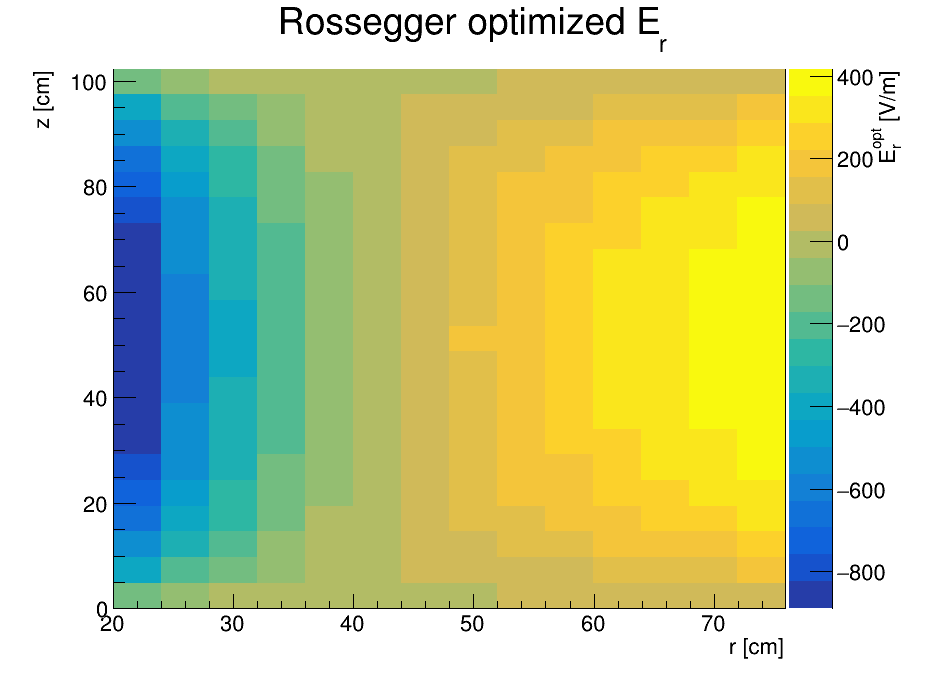

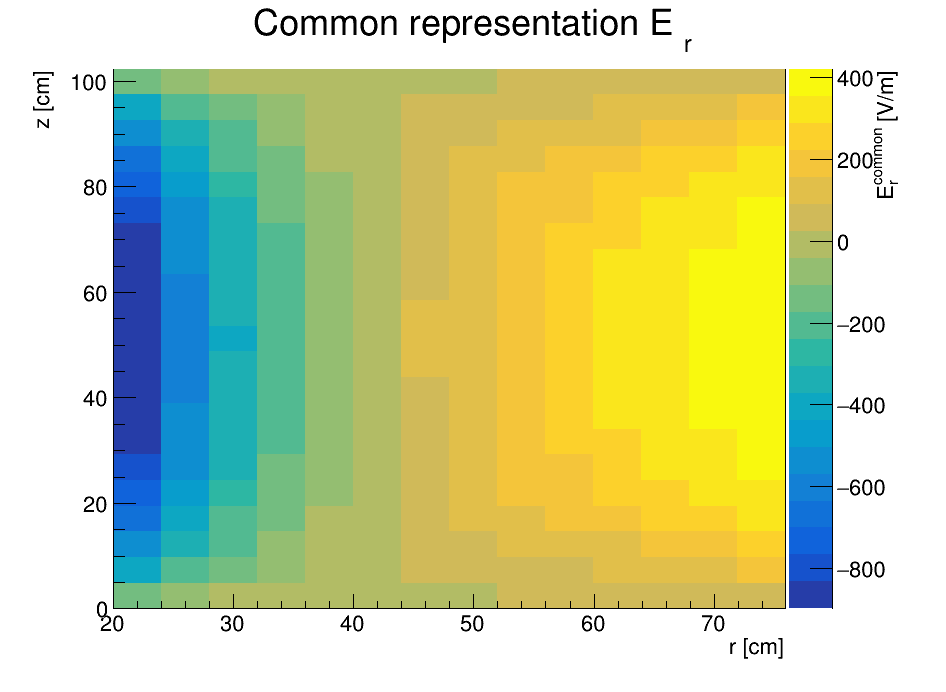

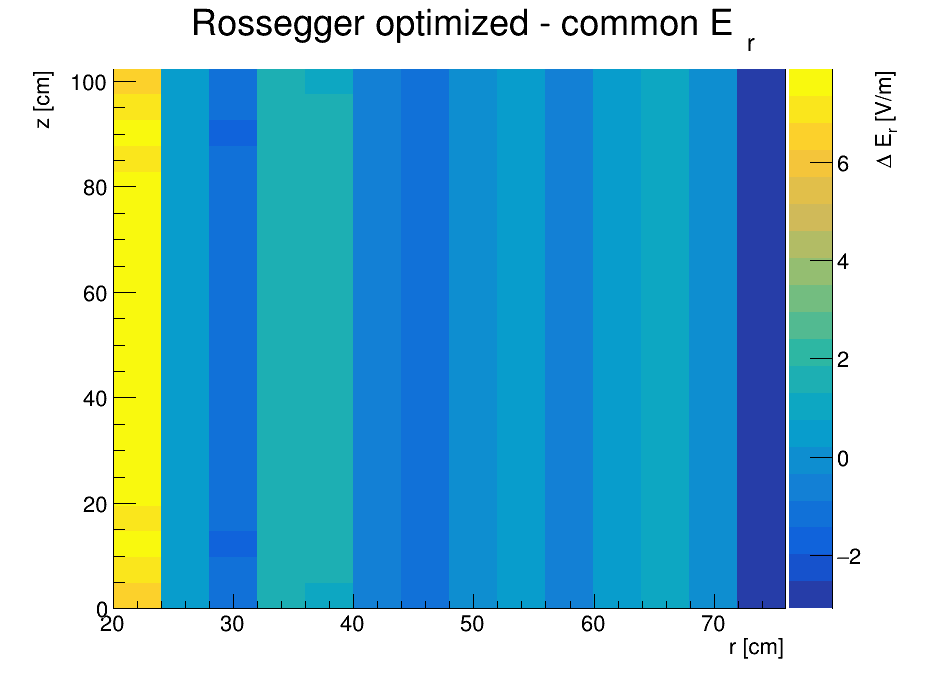

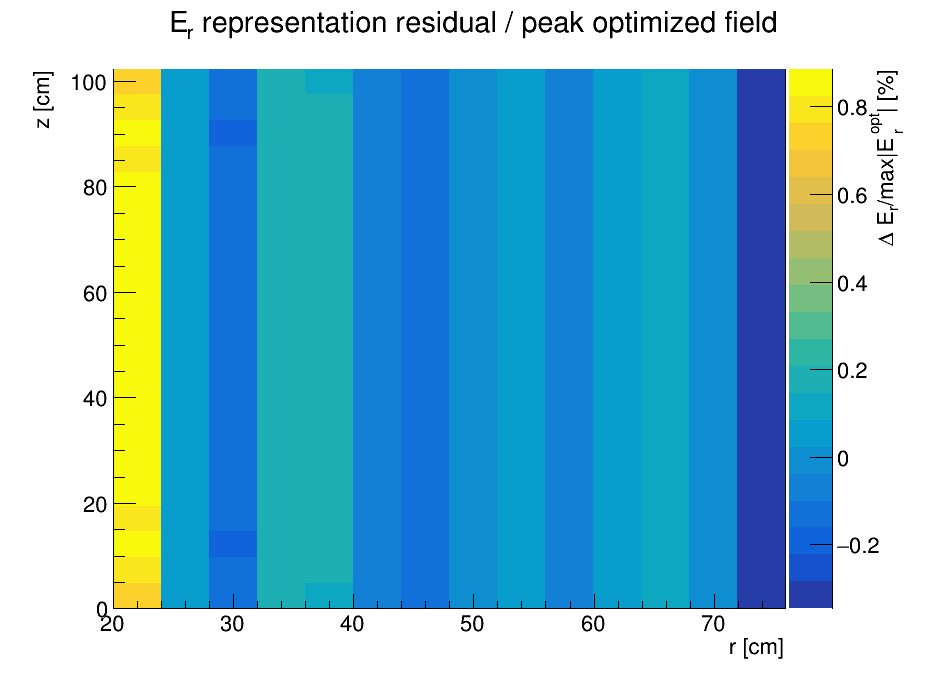

Info in <TCanvas::Print>: png file rossegger3d_qa/qa_Er_rossegger_optimized.png has been created
Info in <TCanvas::Print>: png file rossegger3d_qa/qa_Er_common.png has been created
Info in <TCanvas::Print>: png file rossegger3d_qa/qa_Er_optimized_minus_common.png has been created
Info in <TCanvas::Print>: png file rossegger3d_qa/qa_Er_optimized_minus_common_percent.png has been created


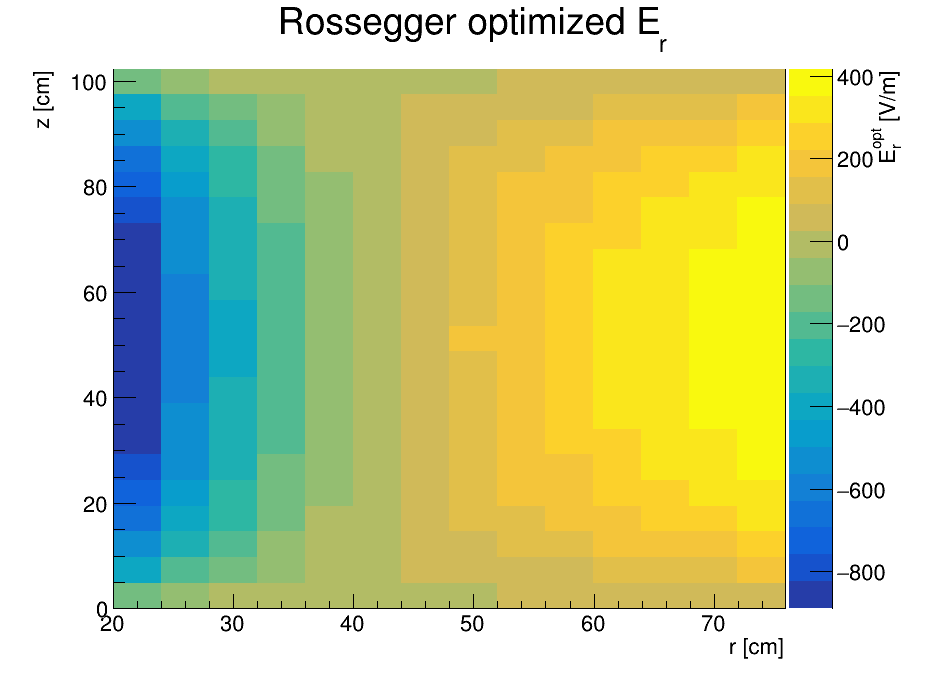

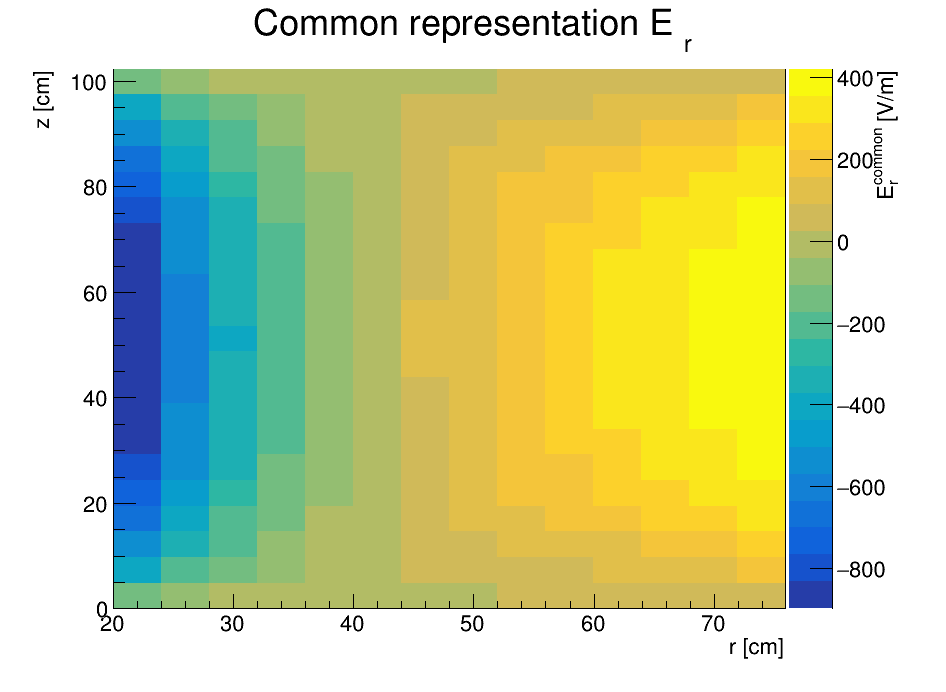

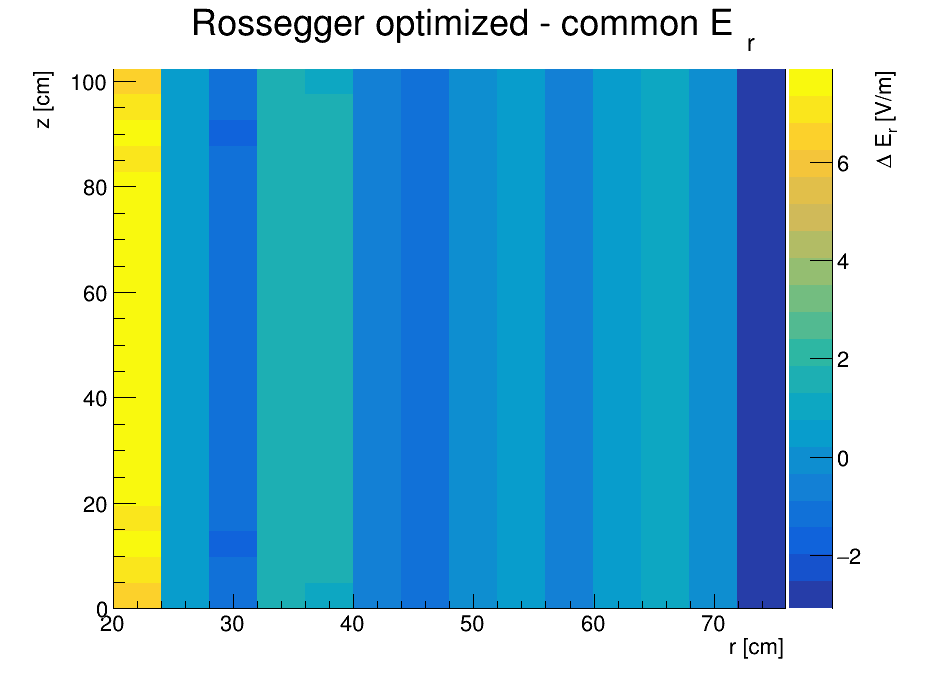

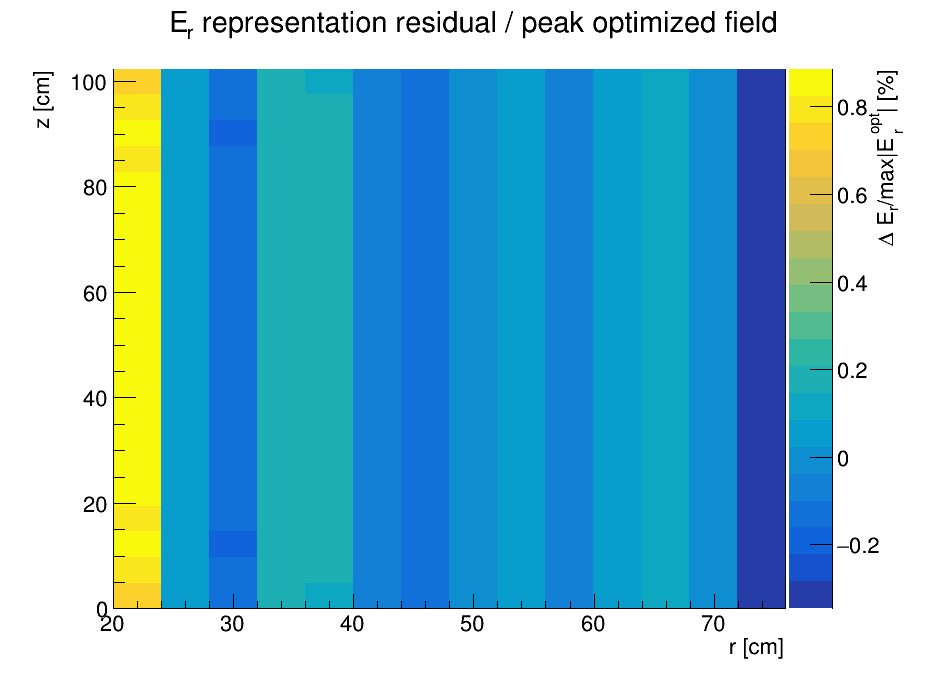

In [13]:
if DO_QA and DO_ROSSEGGER_OPTIMIZED_ER:
    Er_opt_rz = np.mean(E_r_rossegger, axis=1)
    Er_common_rz = np.mean(E_r_common, axis=1)
    Er_diff_rz = Er_opt_rz - Er_common_rz

    peak_opt_er = max(np.max(np.abs(Er_opt_rz)), 1.0e-30)
    Er_diff_percent = 100.0*Er_diff_rz/peak_opt_er

    h_er_opt = make_th2(
        "hErRosseggerOptimized",
        "Rossegger optimized E_{r}",
        Er_opt_rz,
        100*r_obs_edges,
        100*z_obs_edges,
        "r [cm]",
        "z [cm]",
        "E_{r}^{opt} [V/m]"
    )
    draw_th2("qa_Er_rossegger_optimized", h_er_opt)

    h_er_common = make_th2(
        "hErCommonRepresentation",
        "Common representation E_{r}",
        Er_common_rz,
        100*r_obs_edges,
        100*z_obs_edges,
        "r [cm]",
        "z [cm]",
        "E_{r}^{common} [V/m]"
    )
    draw_th2("qa_Er_common", h_er_common)

    h_er_diff = make_th2(
        "hErOptimizedMinusCommon",
        "Rossegger optimized - common E_{r}",
        Er_diff_rz,
        100*r_obs_edges,
        100*z_obs_edges,
        "r [cm]",
        "z [cm]",
        "#Delta E_{r} [V/m]"
    )
    draw_th2("qa_Er_optimized_minus_common", h_er_diff)

    h_er_diff_percent = make_th2(
        "hErOptimizedMinusCommonPercent",
        "E_{r} representation residual / peak optimized field",
        Er_diff_percent,
        100*r_obs_edges,
        100*z_obs_edges,
        "r [cm]",
        "z [cm]",
        "#Delta E_{r}/max|E_{r}^{opt}| [%]"
    )
    draw_th2(
        "qa_Er_optimized_minus_common_percent",
        h_er_diff_percent
    )

### Optimized-\(E_r\) longitudinal-mode convergence

In the modified-Bessel representation, \(E_r\) is a sum over longitudinal sine modes. The values at representative points should approach plateaus as the longitudinal-mode limit is increased.

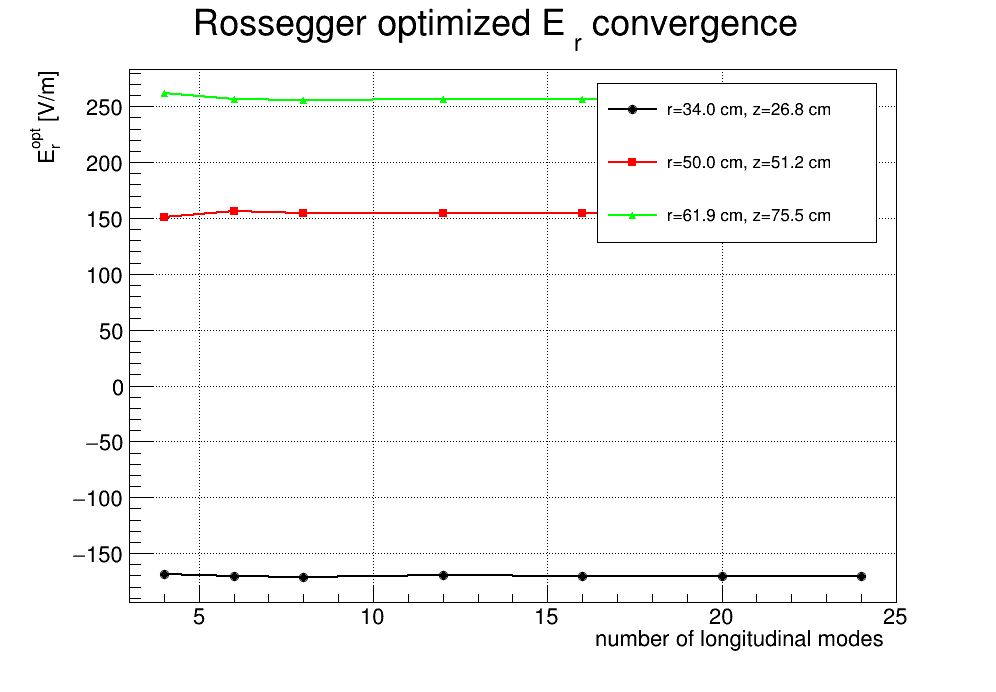

Info in <TCanvas::Print>: png file rossegger3d_qa/qa_Er_optimized_convergence.png has been created


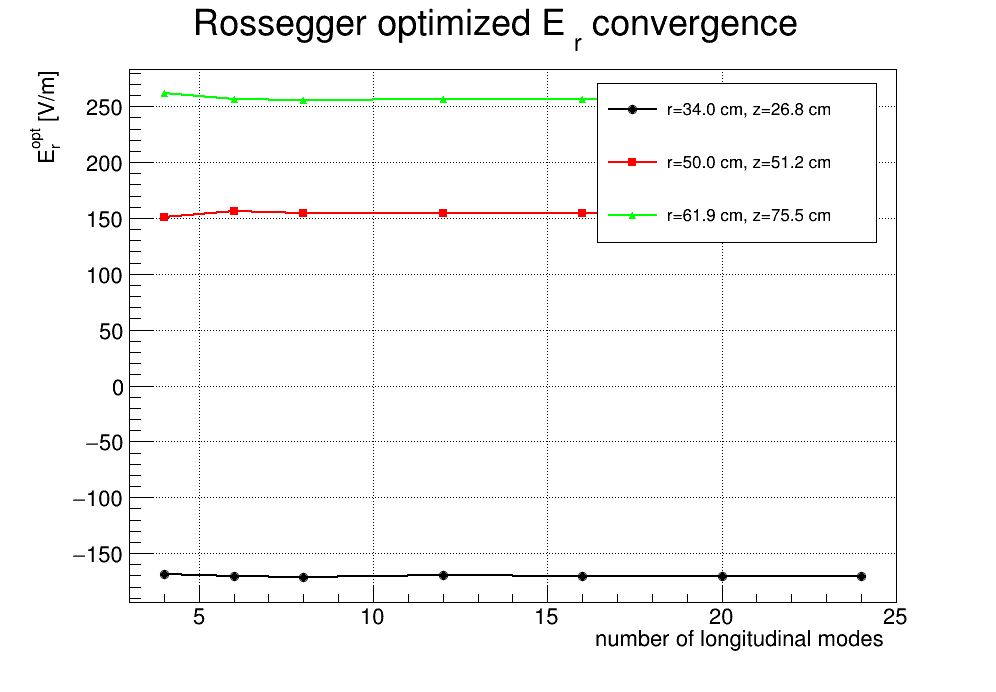

In [14]:
if DO_CONVERGENCE_QA and DO_ROSSEGGER_OPTIMIZED_ER:
    er_mode_counts = sorted(set(
        n for n in OPTIMIZED_ER_CONVERGENCE_MODES
        if 1 <= n <= N_LONGITUDINAL_MODES
    ))

    er_probe_indices = [
        (nr_obs//4, nz_obs//4),
        (nr_obs//2, nz_obs//2),
        (3*nr_obs//4, 3*nz_obs//4),
    ]

    er_convergence_values = {
        probe: []
        for probe in er_probe_indices
    }

    for nmode in er_mode_counts:
        Er_test = build_optimized_er(
            n_longitudinal_modes=nmode
        )
        Er_test_rz = Er_test[:, 0, :]

        for probe in er_probe_indices:
            er_convergence_values[probe].append(
                Er_test_rz[probe]
            )

    c_er_conv = root.TCanvas(
        "qa_Er_optimized_convergence",
        "",
        1000,
        720
    )
    c_er_conv.SetGrid()
    c_er_conv.SetLeftMargin(0.13)
    c_er_conv.SetBottomMargin(0.13)

    mg_er_conv = root.TMultiGraph()
    leg_er_conv = root.TLegend(0.60, 0.65, 0.88, 0.88)
    er_conv_graphs = []

    for ig, probe in enumerate(er_probe_indices):
        ir, iz = probe
        g = graph_from_xy(
            er_mode_counts,
            er_convergence_values[probe],
            f"gErOptConv_{ig}",
            "",
            "number of longitudinal modes",
            "E_{r}^{opt} [V/m]"
        )
        g.SetLineColor(ig+1)
        g.SetMarkerColor(ig+1)
        g.SetMarkerStyle(20+ig)
        mg_er_conv.Add(g, "LP")
        leg_er_conv.AddEntry(
            g,
            (
                f"r={100*r_obs[ir]:.1f} cm, "
                f"z={100*z_obs[iz]:.1f} cm"
            ),
            "lp"
        )
        er_conv_graphs.append(g)
        qa_objects.append(g)

    mg_er_conv.SetTitle(
        "Rossegger optimized E_{r} convergence;"
        "number of longitudinal modes;"
        "E_{r}^{opt} [V/m]"
    )
    mg_er_conv.Draw("A")
    leg_er_conv.Draw()

    c_er_conv.Update()
    png = str(
        Path(QA_PLOT_DIRECTORY)
        / "qa_Er_optimized_convergence.png"
    )
    c_er_conv.SaveAs(png)
    display(Image(filename=png))

    qa_canvases.append(c_er_conv)

### Visible comparison of the two \(E_z\) representations

The following QA shows the optimized result, common result, their difference, and the residual normalized to the peak optimized field.

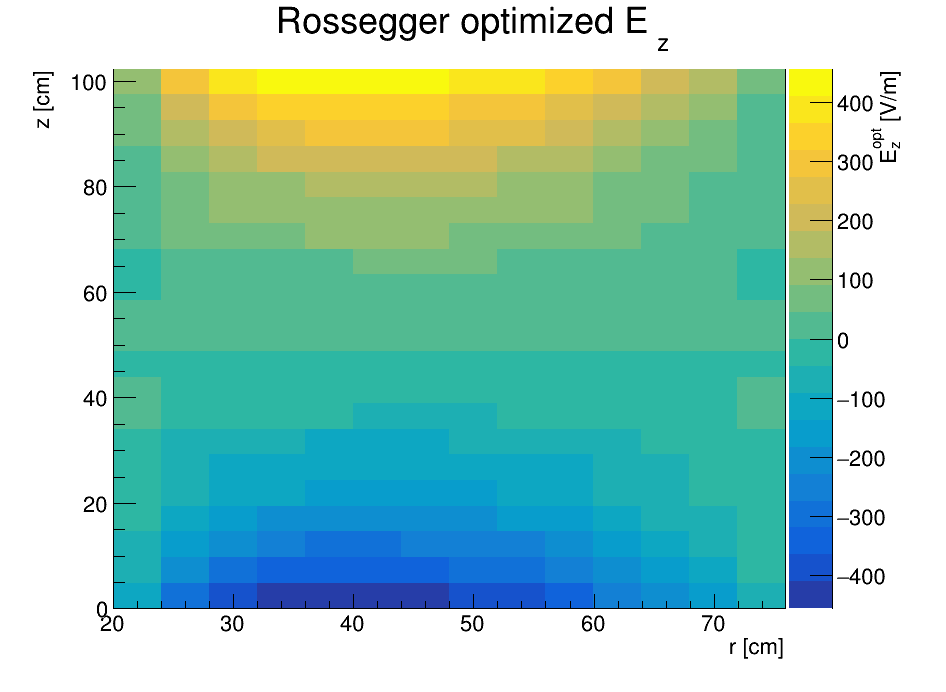

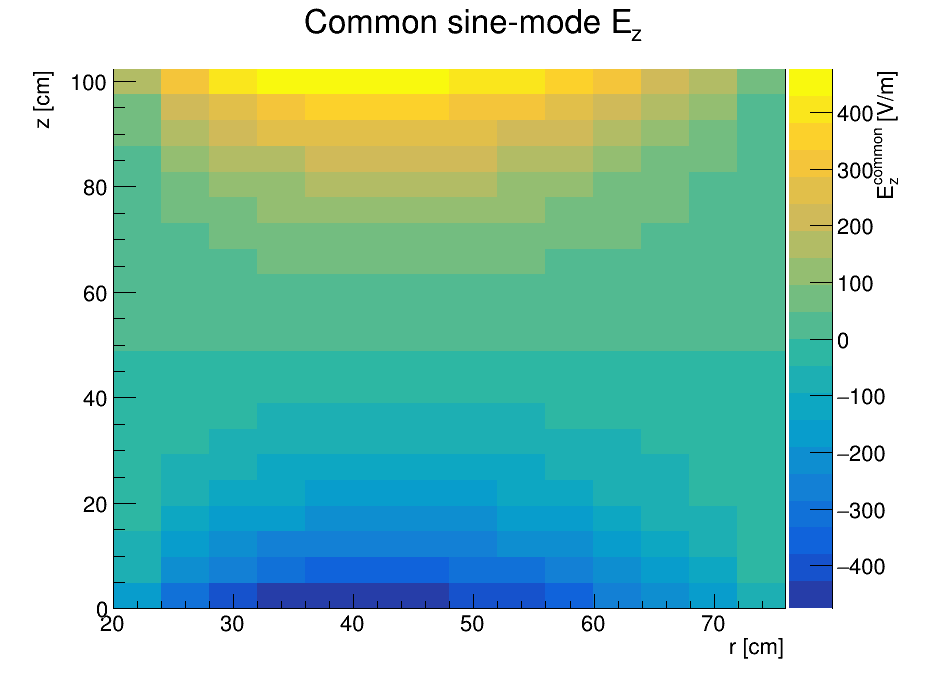

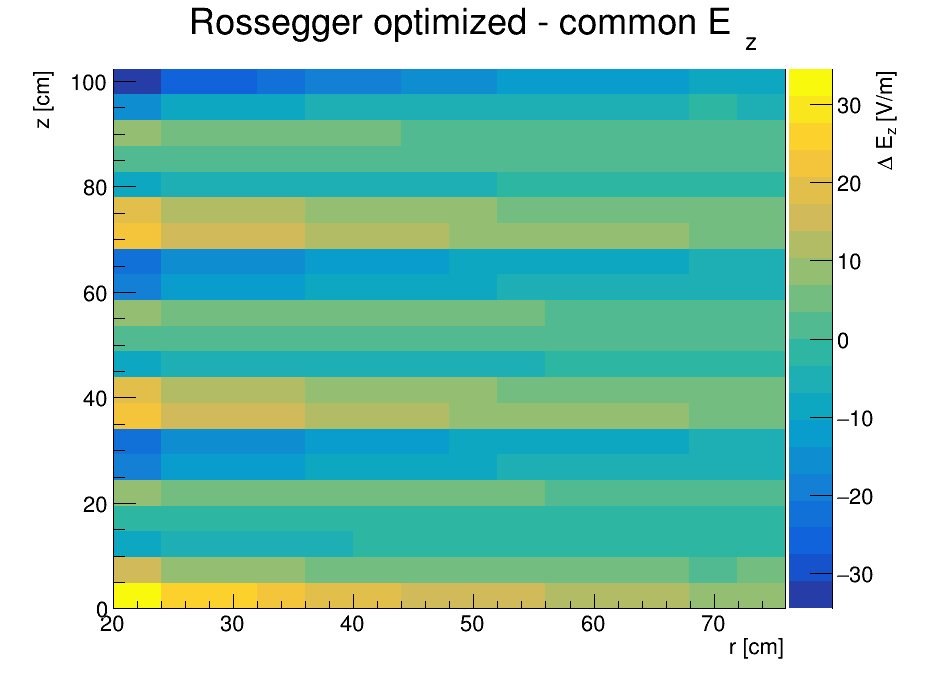

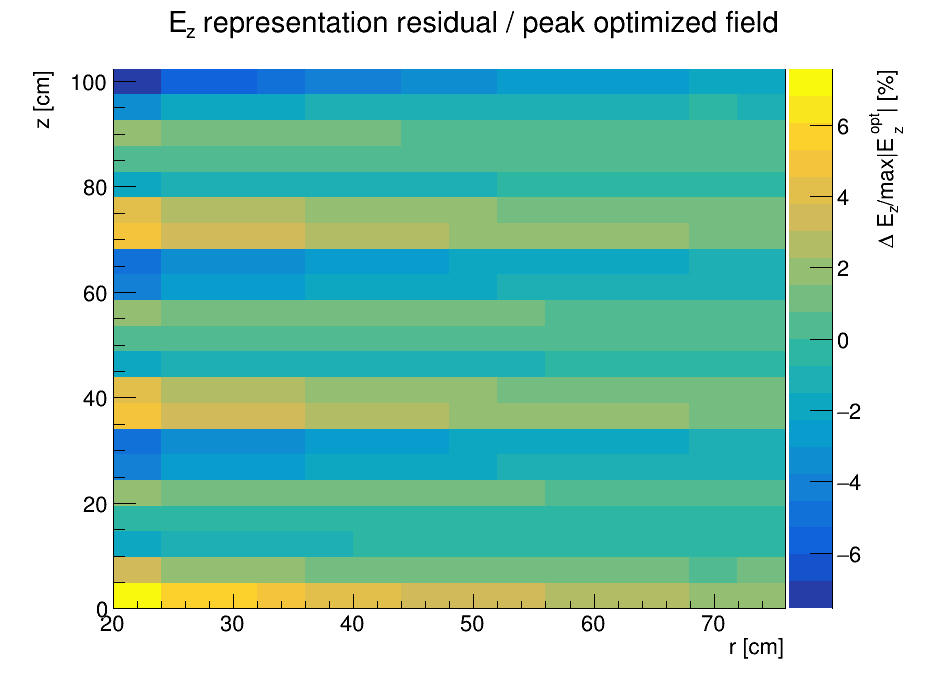

Info in <TCanvas::Print>: png file rossegger3d_qa/qa_Ez_rossegger_optimized.png has been created
Info in <TCanvas::Print>: png file rossegger3d_qa/qa_Ez_common.png has been created
Info in <TCanvas::Print>: png file rossegger3d_qa/qa_Ez_optimized_minus_common.png has been created
Info in <TCanvas::Print>: png file rossegger3d_qa/qa_Ez_optimized_minus_common_percent.png has been created


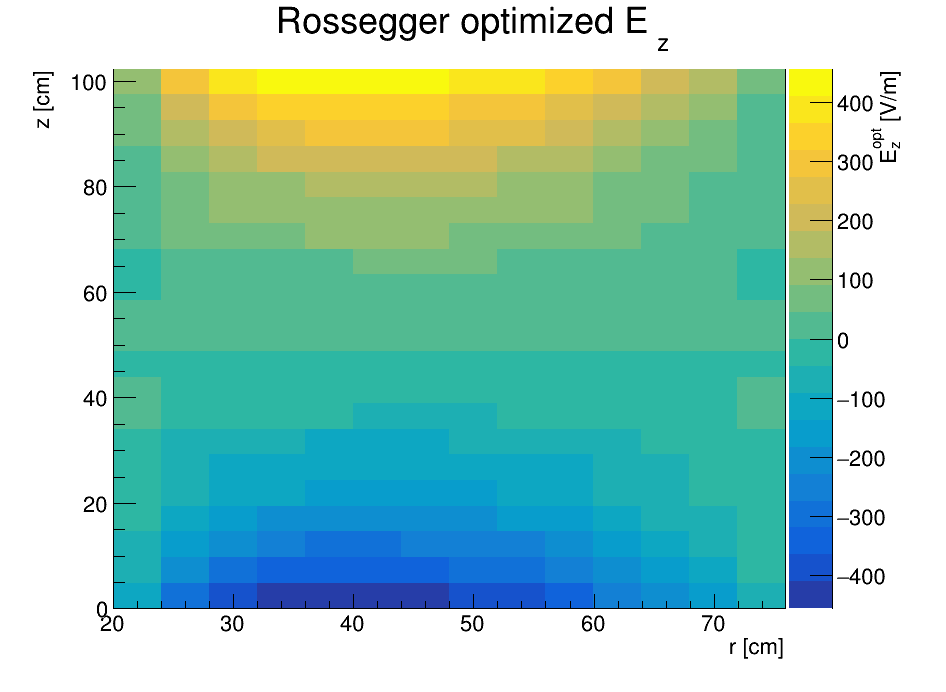

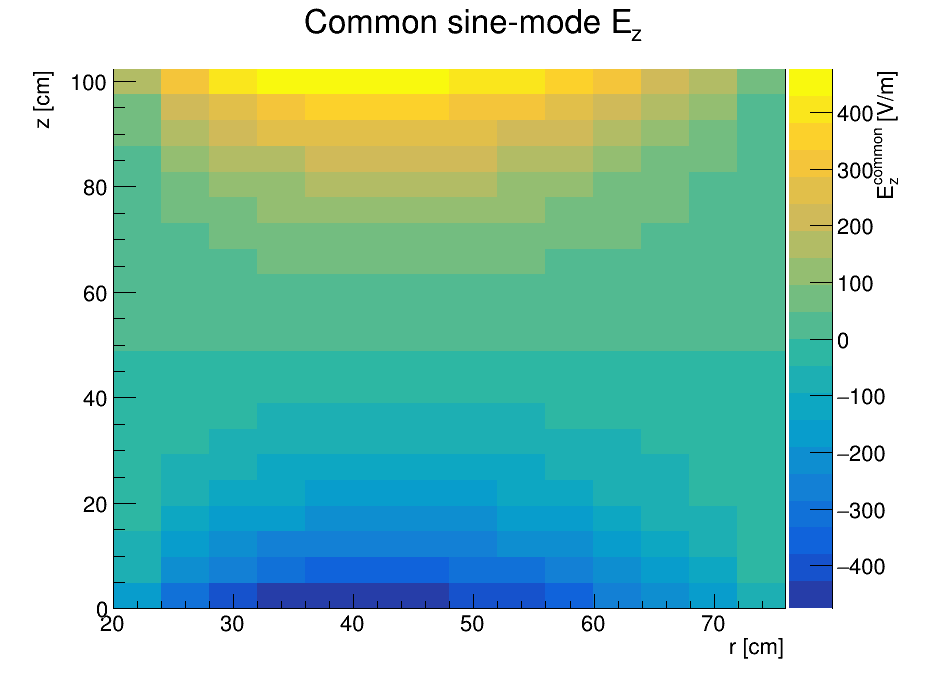

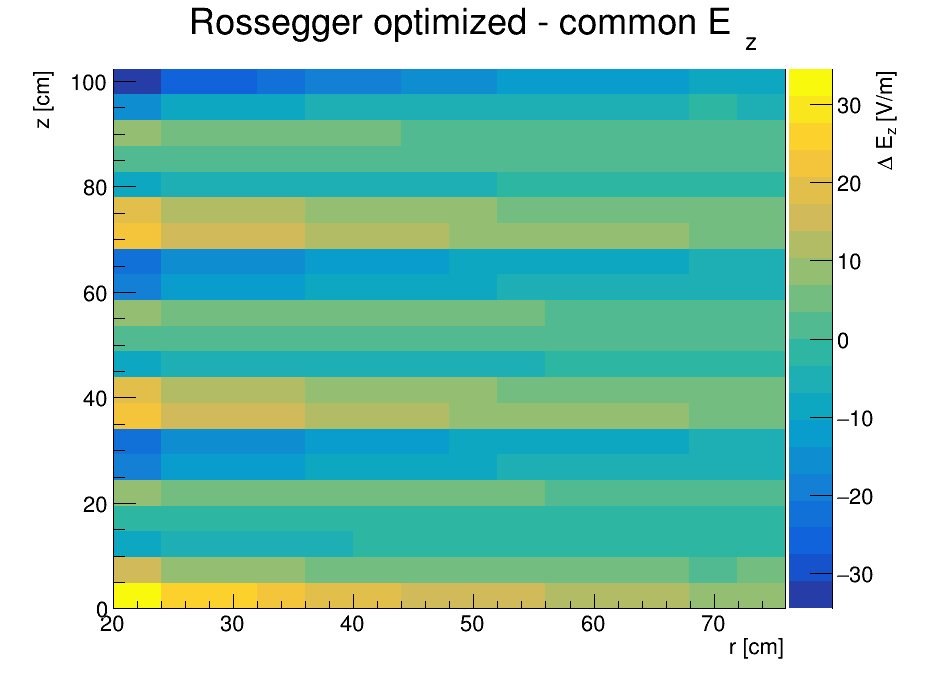

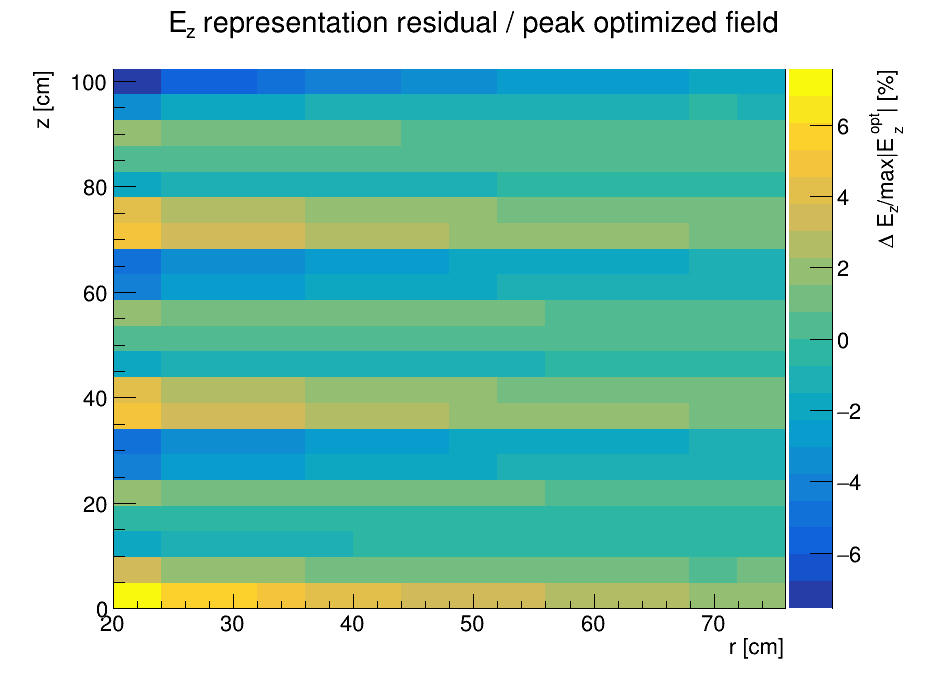

In [15]:
if DO_QA and DO_ROSSEGGER_OPTIMIZED_EZ:
    Ez_opt_rz = np.mean(E_z_rossegger, axis=1)
    Ez_common_rz = np.mean(E_z_common, axis=1)
    Ez_diff_rz = Ez_opt_rz - Ez_common_rz

    peak_opt = max(np.max(np.abs(Ez_opt_rz)), 1.0e-30)
    Ez_diff_percent = 100.0*Ez_diff_rz/peak_opt

    h_ez_opt = make_th2(
        "hEzRosseggerOptimized",
        "Rossegger optimized E_{z}",
        Ez_opt_rz,
        100*r_obs_edges,
        100*z_obs_edges,
        "r [cm]",
        "z [cm]",
        "E_{z}^{opt} [V/m]"
    )
    draw_th2("qa_Ez_rossegger_optimized", h_ez_opt)

    h_ez_common = make_th2(
        "hEzCommonRepresentation",
        "Common sine-mode E_{z}",
        Ez_common_rz,
        100*r_obs_edges,
        100*z_obs_edges,
        "r [cm]",
        "z [cm]",
        "E_{z}^{common} [V/m]"
    )
    draw_th2("qa_Ez_common", h_ez_common)

    h_ez_diff = make_th2(
        "hEzOptimizedMinusCommon",
        "Rossegger optimized - common E_{z}",
        Ez_diff_rz,
        100*r_obs_edges,
        100*z_obs_edges,
        "r [cm]",
        "z [cm]",
        "#Delta E_{z} [V/m]"
    )
    draw_th2("qa_Ez_optimized_minus_common", h_ez_diff)

    h_ez_diff_percent = make_th2(
        "hEzOptimizedMinusCommonPercent",
        "E_{z} representation residual / peak optimized field",
        Ez_diff_percent,
        100*r_obs_edges,
        100*z_obs_edges,
        "r [cm]",
        "z [cm]",
        "#Delta E_{z}/max|E_{z}^{opt}| [%]"
    )
    draw_th2(
        "qa_Ez_optimized_minus_common_percent",
        h_ez_diff_percent
    )

### Optimized-\(E_z\) radial-mode convergence

The optimized representation contains only the radial eigenmode sum; its longitudinal dependence is retained analytically. The curves should approach plateaus as the radial-mode limit increases.

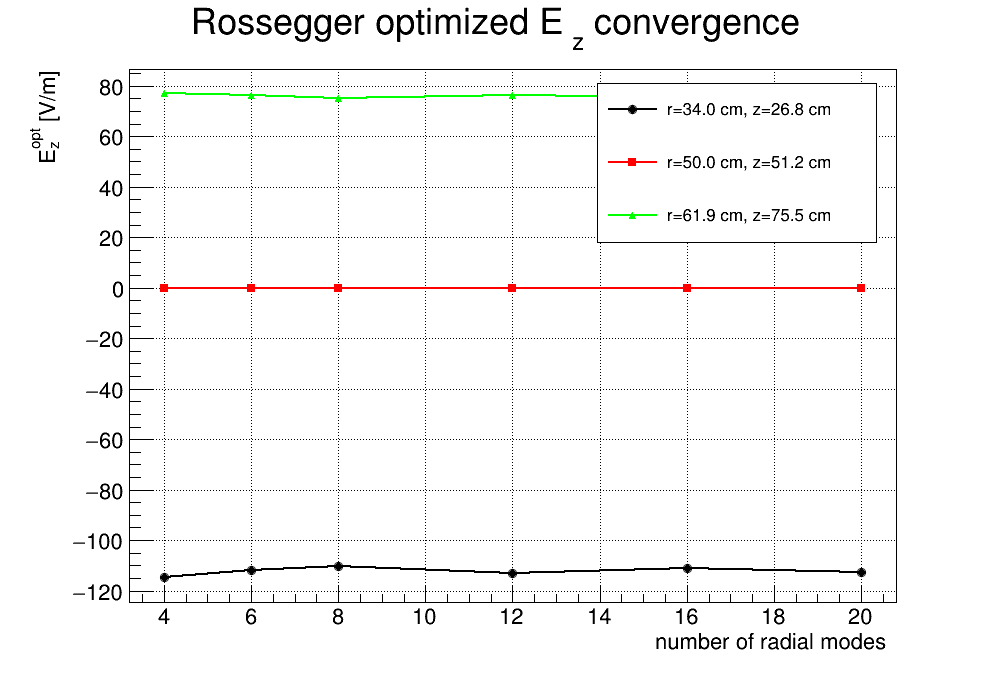

Info in <TCanvas::Print>: png file rossegger3d_qa/qa_Ez_optimized_convergence.png has been created


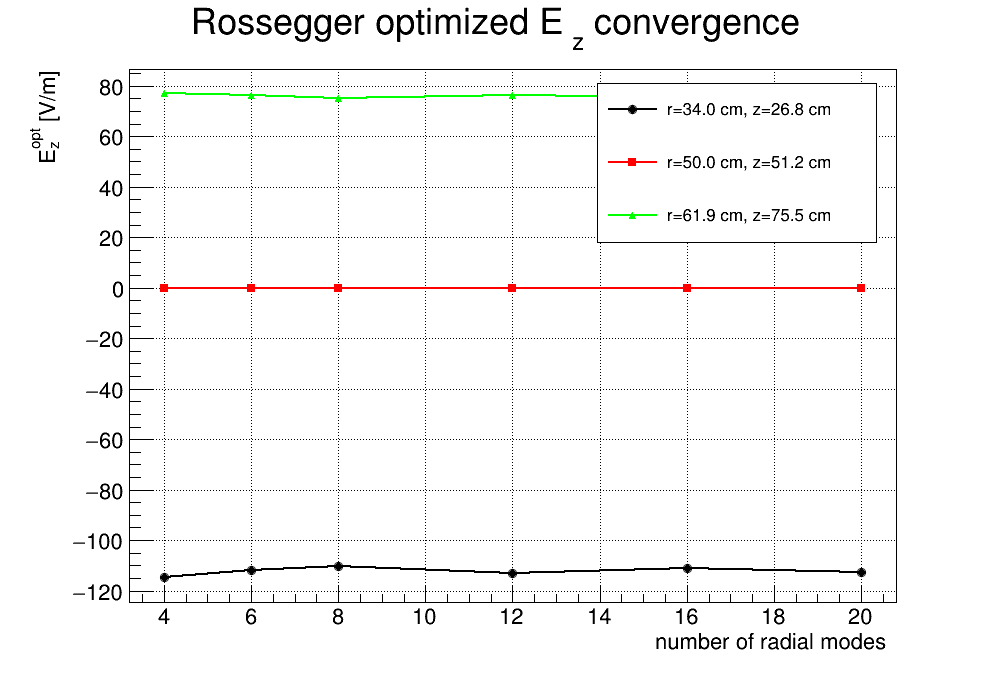

In [16]:
if DO_CONVERGENCE_QA and DO_ROSSEGGER_OPTIMIZED_EZ:
    mode_counts = sorted(set(
        n for n in OPTIMIZED_EZ_CONVERGENCE_MODES
        if 1 <= n <= N_RADIAL_MODES
    ))

    probe_indices = [
        (nr_obs//4, nz_obs//4),
        (nr_obs//2, nz_obs//2),
        (3*nr_obs//4, 3*nz_obs//4),
    ]

    convergence_values = {
        probe: []
        for probe in probe_indices
    }

    for nmode in mode_counts:
        Ez_test = build_optimized_ez(n_radial_modes=nmode)
        Ez_test_rz = Ez_test[:, 0, :]

        for probe in probe_indices:
            convergence_values[probe].append(
                Ez_test_rz[probe]
            )

    c_ez_conv = root.TCanvas(
        "qa_Ez_optimized_convergence",
        "",
        1000,
        720
    )
    c_ez_conv.SetGrid()
    c_ez_conv.SetLeftMargin(0.13)
    c_ez_conv.SetBottomMargin(0.13)

    mg_ez_conv = root.TMultiGraph()
    leg_ez_conv = root.TLegend(0.60, 0.65, 0.88, 0.88)
    ez_conv_graphs = []

    for ig, probe in enumerate(probe_indices):
        ir, iz = probe
        g = graph_from_xy(
            mode_counts,
            convergence_values[probe],
            f"gEzOptConv_{ig}",
            "",
            "number of radial modes",
            "E_{z}^{opt} [V/m]"
        )
        g.SetLineColor(ig+1)
        g.SetMarkerColor(ig+1)
        g.SetMarkerStyle(20+ig)
        mg_ez_conv.Add(g, "LP")
        leg_ez_conv.AddEntry(
            g,
            (
                f"r={100*r_obs[ir]:.1f} cm, "
                f"z={100*z_obs[iz]:.1f} cm"
            ),
            "lp"
        )
        ez_conv_graphs.append(g)
        qa_objects.append(g)

    mg_ez_conv.SetTitle(
        "Rossegger optimized E_{z} convergence;"
        "number of radial modes;"
        "E_{z}^{opt} [V/m]"
    )
    mg_ez_conv.Draw("A")
    leg_ez_conv.Draw()

    c_ez_conv.Update()
    png = str(
        Path(QA_PLOT_DIRECTORY)
        / "qa_Ez_optimized_convergence.png"
    )
    c_ez_conv.SaveAs(png)
    display(Image(filename=png))

    qa_canvases.append(c_ez_conv)

## 6c. Final component consistency QA

The production maps now use the component-specific Rossegger representations:

- \(E_r\): modified-Bessel radial Green function;
- \(E_z\): ordinary-Bessel radial eigenmodes with hyperbolic longitudinal Green function;
- \(E_\phi=0\): exact for the current axisymmetric baseline.

The following checks verify that:

- both maps are finite;
- \(E_r\) approaches zero at the longitudinal end planes;
- \(E_z\) is antisymmetric around \(L/2\) for a \(z\)-uniform source;
- the final field remains consistent with Gauss's law.

In [17]:
if DO_QA:
    if not np.all(np.isfinite(E_r)):
        raise RuntimeError("Final E_r contains non-finite values.")
    if not np.all(np.isfinite(E_z)):
        raise RuntimeError("Final E_z contains non-finite values.")

    Er_rz_final = np.mean(E_r, axis=1)
    Ez_rz_final = np.mean(E_z, axis=1)

    er_ref = max(np.max(np.abs(Er_rz_final)), 1.0e-30)
    ez_ref = max(np.max(np.abs(Ez_rz_final)), 1.0e-30)

    er_z_reflection = np.max(
        np.abs(Er_rz_final - Er_rz_final[:, ::-1])
    ) / er_ref

    ez_z_reflection = np.max(
        np.abs(Ez_rz_final + Ez_rz_final[:, ::-1])
    ) / ez_ref

    print("Final component consistency:")
    print("  Er even-reflection residual =", er_z_reflection)
    print("  Ez odd-reflection residual  =", ez_z_reflection)
    print("  max |Ephi|                  =", np.max(np.abs(E_phi)))

    if er_z_reflection > 5e-3:
        print(
            "WARNING: Er reflection residual exceeds 0.5%; "
            "increase the optimized Er longitudinal-mode count."
        )

    if ez_z_reflection > 5e-3:
        print(
            "WARNING: Ez reflection residual exceeds 0.5%; "
            "increase the optimized Ez radial-mode count."
        )

Final component consistency:
  Er even-reflection residual = 6.702589734019735e-16
  Ez odd-reflection residual  = 1.3701292908643006e-15
  max |Ephi|                  = 0.0


## 7. Visible field QA

When `DO_PHI_QA = False`, the notebook does not produce any plot whose main purpose is to display azimuthal structure. It shows only:

- azimuthally averaged \(\rho(r,z)\);
- azimuthally averaged \(E_r(r,z)\);
- azimuthally averaged \(E_z(r,z)\);
- radial and longitudinal convergence;
- boundary and Gauss-law tests.

This is the recommended mode for the present physical baseline, where the source is uniform in \(\phi\).

When a measured non-axisymmetric source becomes available, set:

```python
AXISYMMETRIC_BASELINE = False
DO_PHI_QA = True
WRITE_EPHI_MAP = True
```

and choose a nonzero `M_PHI_EFFECTIVE_MAX`.

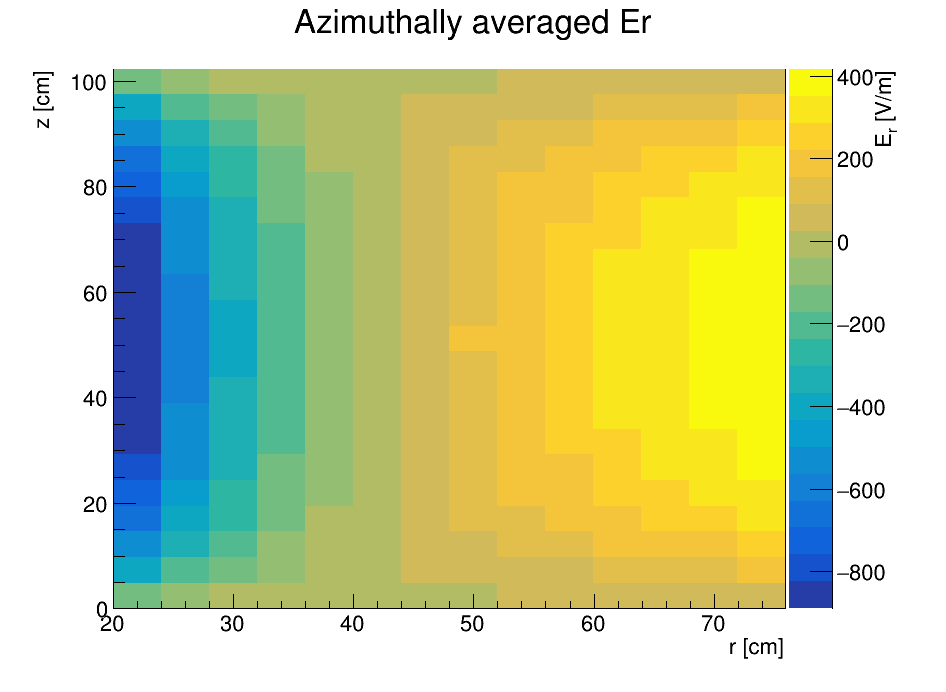

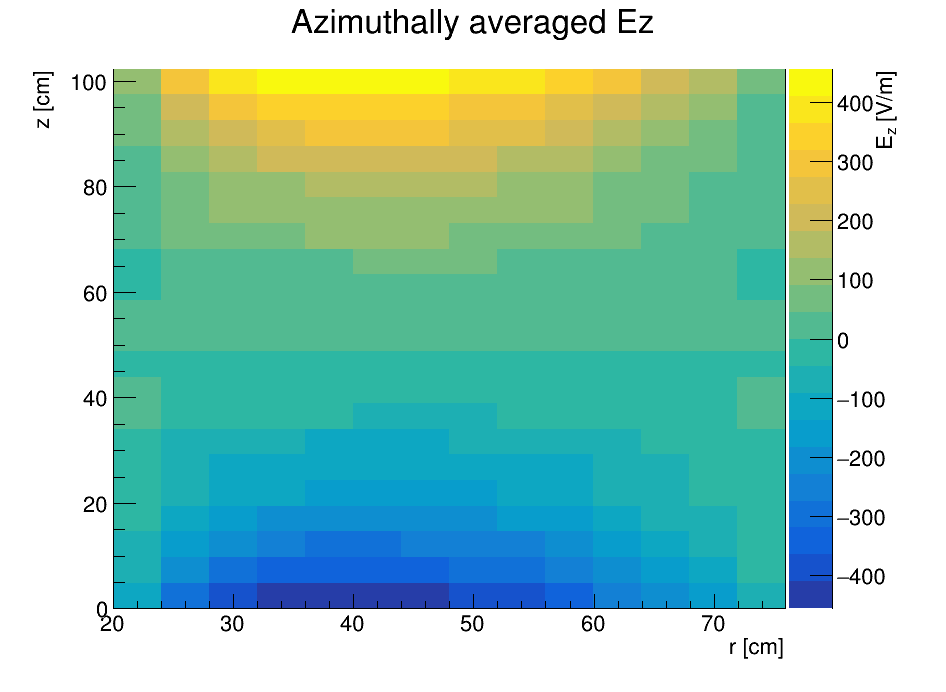

Info in <TCanvas::Print>: png file rossegger3d_qa/qa_Er_rz.png has been created
Info in <TCanvas::Print>: png file rossegger3d_qa/qa_Ez_rz.png has been created


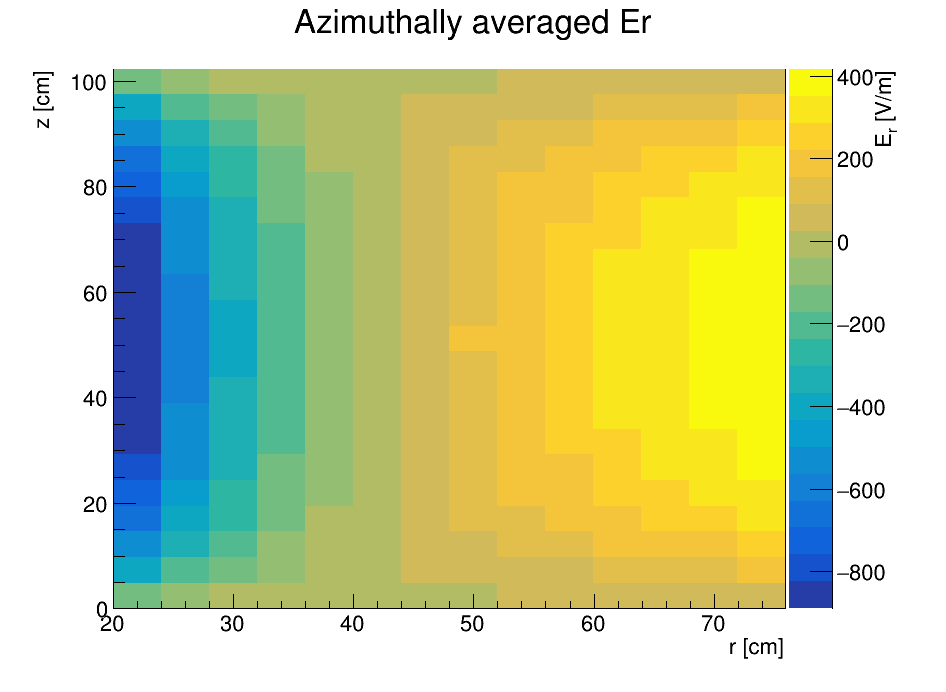

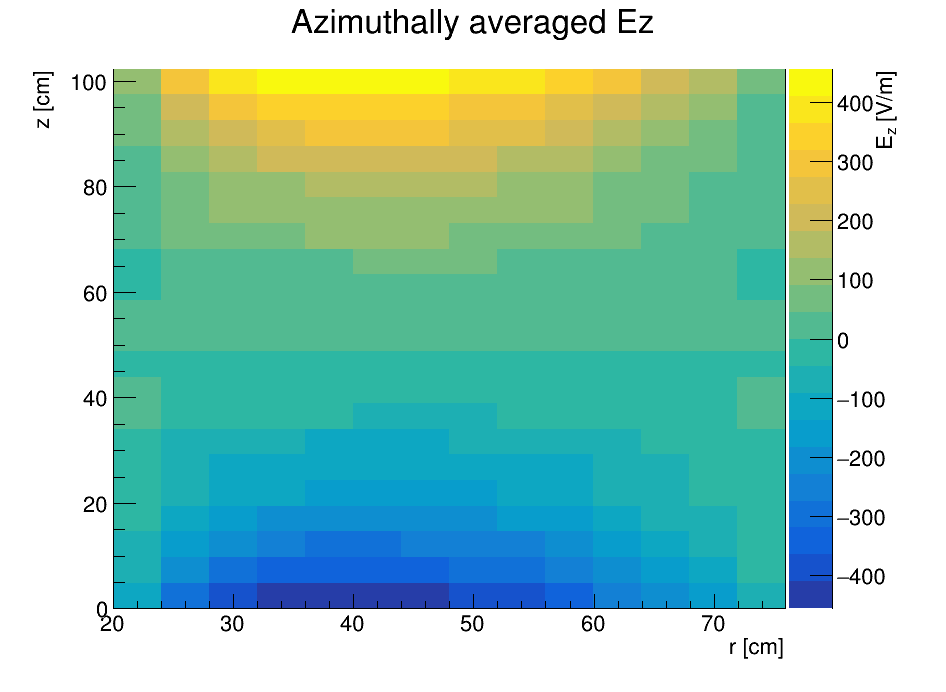

In [18]:
if DO_QA:
    ip = 0

    components = [
        ("Er", E_r, "E_{r} [V/m]"),
        ("Ez", E_z, "E_{z} [V/m]"),
    ]
    if DO_PHI_QA:
        components.insert(1, ("Ephi", E_phi, "E_{#phi} [V/m]"))

    for comp_name, data, ztitle in components:
        # For the axisymmetric baseline, average over phi before plotting.
        data_rz = np.mean(data, axis=1)

        h = make_th2(
            f"h{comp_name}RZ",
            f"Azimuthally averaged {comp_name}",
            data_rz,
            100*r_obs_edges, 100*z_obs_edges,
            "r [cm]", "z [cm]", ztitle
        )
        draw_th2(f"qa_{comp_name}_rz", h)

        if DO_PHI_QA:
            iz = nz_obs//2
            ir = nr_obs//2

            h = make_th2(
                f"h{comp_name}RPhi",
                f"{comp_name} at z={100*z_obs[iz]:.1f} cm",
                data[:,:,iz],
                100*r_obs_edges, phi_obs_edges,
                "r [cm]", "#phi [rad]", ztitle
            )
            draw_th2(f"qa_{comp_name}_rphi", h)

            h = make_th2(
                f"h{comp_name}PhiZ",
                f"{comp_name} at r={100*r_obs[ir]:.1f} cm",
                data[ir,:,:],
                phi_obs_edges, 100*z_obs_edges,
                "#phi [rad]", "z [cm]", ztitle
            )
            draw_th2(f"qa_{comp_name}_phiz", h)

## QA: Rossegger Green functions used in the final component-optimized solver

The final axisymmetric production solver uses two different component-specific Green-function representations:

- For $E_z$, the ordinary-Bessel radial expansion is combined with the longitudinal hyperbolic Green function
  $$
  G_k(z,z')
  =
  \frac{\sinh(k z_<)\sinh[k(L-z_>)]}{k\sinh(kL)},
  $$
  and the field uses
  $$
  \frac{\partial G_k(z,z')}{\partial z}.
  $$

- For $E_r$, the longitudinal dependence is expanded in sine modes, while the radial Green function is written in modified-Bessel form
  $$
  g_l(r,r')
  =
  -\frac{u_l(r_<)\,v_l(r_>)}{C_l},
  $$
  with
  $$
  u_l(a)=0,\qquad v_l(b)=0.
  $$
  The radial field uses
  $$
  \frac{\partial g_l(r,r')}{\partial r}.
  $$

These plots show the actual kernels used in the final solver and allow qualitative comparison to public Rossegger-style illustrations.

## 8. Axisymmetric-limit QA

A complete 3D implementation must reduce exactly to the axisymmetric solution when all \(m>0\) source coefficients vanish.

This QA recalculates the field with only \(m=0\).

Expected results:

$$
E_\phi^{(m=0)}=0,
$$

and each field component is independent of observation \(\phi\).

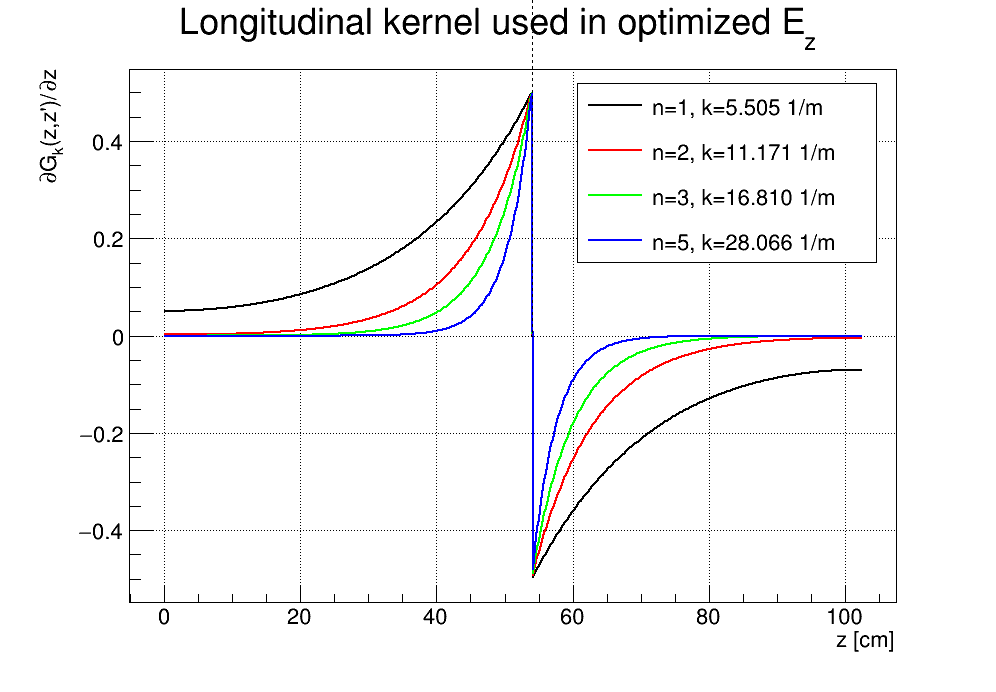

Info in <TCanvas::Print>: png file rossegger3d_qa/qa_rossegger_dGdz.png has been created


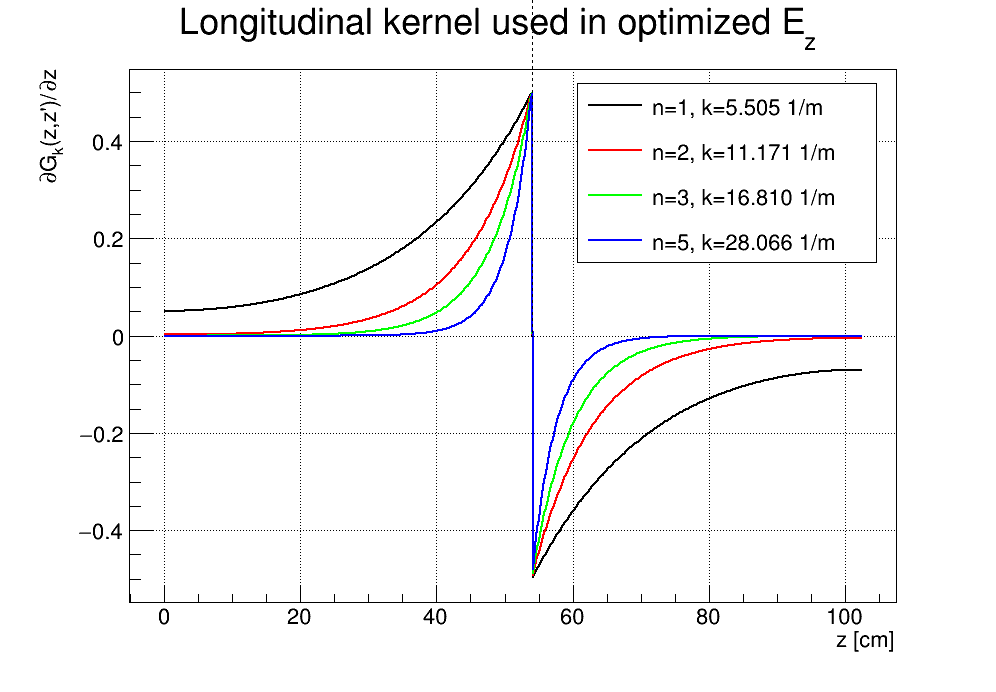

In [27]:
# ============================================================
# QA: longitudinal Green-function derivative used for Ez
# ============================================================

if DO_QA:
    zprime_cm = 54.0
    zprime = zprime_cm * CM_TO_M

    z_plot = np.linspace(0.0, L, 600)

    # Use a few actual radial eigenvalues from m=0
    k_indices = [0, 1, 2, 4]
    k_indices = [i for i in k_indices if i < len(k_modes[0])]

    c_gz = root.TCanvas("qa_rossegger_dGdz", "", 1000, 720)
    c_gz.SetGrid()
    c_gz.SetLeftMargin(0.13)
    c_gz.SetBottomMargin(0.13)

    mg_gz = root.TMultiGraph()
    leg_gz = root.TLegend(0.58, 0.62, 0.88, 0.88)

    gz_graphs = []

    for icolor, idx in enumerate(k_indices, start=1):
        kval = k_modes[0][idx]
        yvals = np.array([
            d_green_z_dz(kval, zval, zprime)
            for zval in z_plot
        ])

        g = graph_from_xy(
            100.0 * z_plot,
            yvals,
            f"g_dGdz_k{idx}",
            "",
            "z [cm]",
            "#partialG_{k}(z,z')/#partialz"
        )
        g.SetLineColor(icolor)
        g.SetMarkerColor(icolor)
        g.SetLineWidth(2)

        mg_gz.Add(g, "L")
        leg_gz.AddEntry(
            g,
            f"n={idx+1}, k={kval:.3f} 1/m",
            "l"
        )

        gz_graphs.append(g)
        qa_objects.append(g)

    mg_gz.SetTitle(
        f"Longitudinal kernel used in optimized E_{{z}};z [cm];"
        "#partialG_{k}(z,z')/#partialz"
    )
    mg_gz.Draw("A")
    leg_gz.Draw()

    # draw source position line
    line = root.TLine(zprime_cm, root.gPad.GetUymin(), zprime_cm, root.gPad.GetUymax())
    line.SetLineStyle(2)
    line.Draw()

    c_gz.Update()
    png = str(Path(QA_PLOT_DIRECTORY) / "qa_rossegger_dGdz.png")
    c_gz.SaveAs(png)
    display(Image(filename=png))

    qa_canvases.append(c_gz)

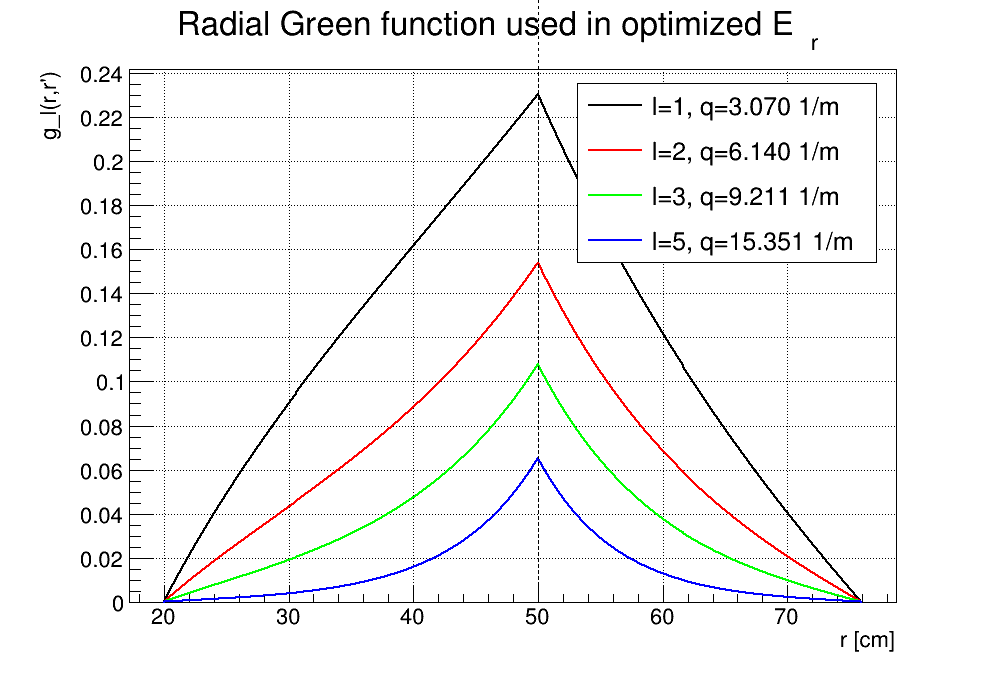

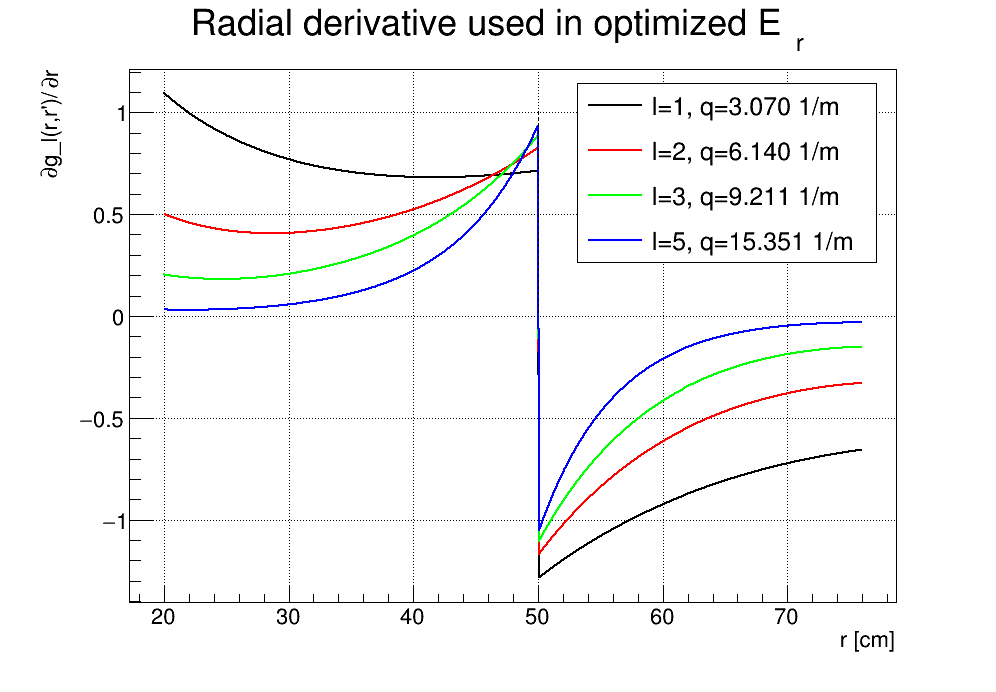

Info in <TCanvas::Print>: png file rossegger3d_qa/qa_rossegger_gr.png has been created
Info in <TCanvas::Print>: png file rossegger3d_qa/qa_rossegger_dgdr.png has been created


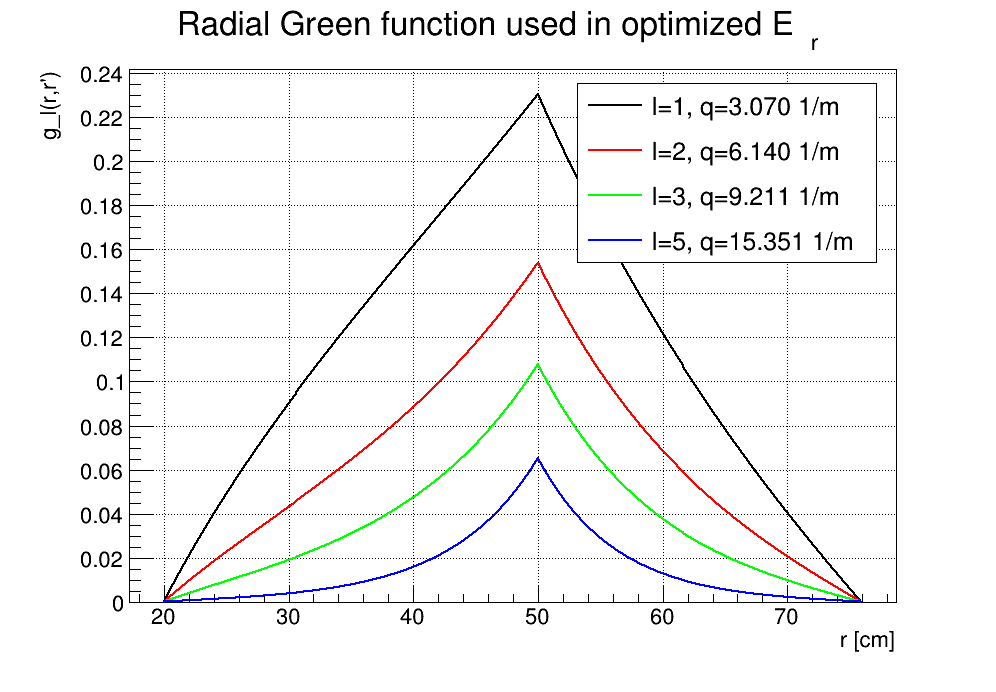

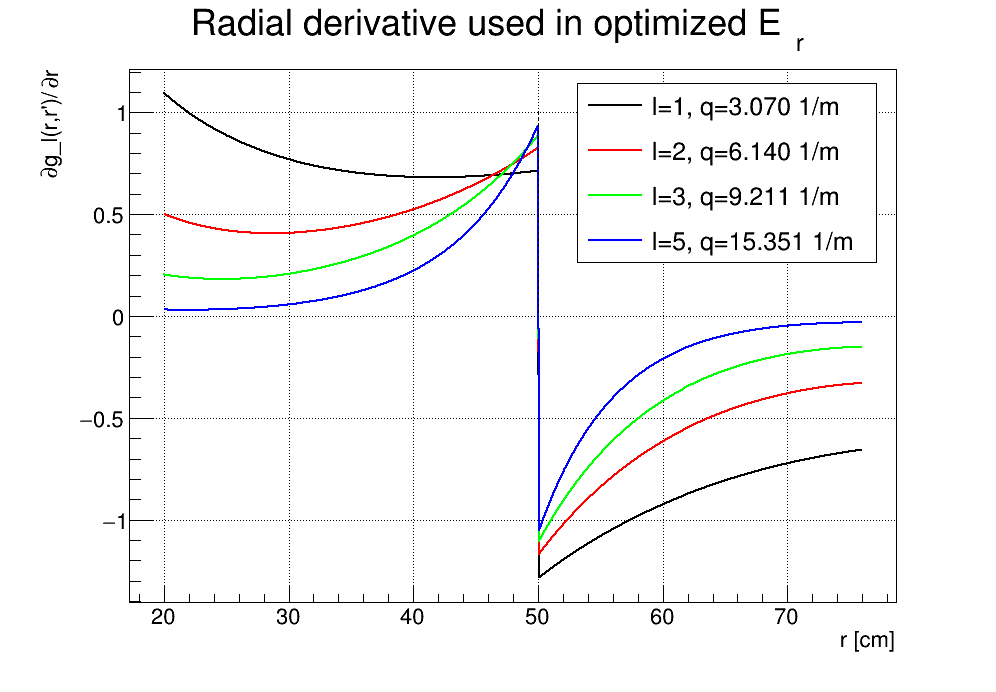

In [28]:
# ============================================================
# QA: radial Green function and derivative used for Er
# ============================================================

if DO_QA:
    rprime_cm = 50.0
    rprime = rprime_cm * CM_TO_M

    r_plot = np.linspace(a, b, 700)

    l_indices = [0, 1, 2, 4]
    l_indices = [i for i in l_indices if i < len(q_modes)]

    # ---- plot g_l(r,r')
    c_gr = root.TCanvas("qa_rossegger_gr", "", 1000, 720)
    c_gr.SetGrid()
    c_gr.SetLeftMargin(0.13)
    c_gr.SetBottomMargin(0.13)

    mg_gr = root.TMultiGraph()
    leg_gr = root.TLegend(0.58, 0.62, 0.88, 0.88)

    gr_graphs = []

    for icolor, idx in enumerate(l_indices, start=1):
        qval = q_modes[idx]
        u, du, v, dv, C = radial_modified_bessel_parts(qval)

        yvals = []
        for rval in r_plot:
            rmin = min(rval, rprime)
            rmax = max(rval, rprime)
            yvals.append(-u(rmin) * v(rmax) / C)

        yvals = np.array(yvals)

        g = graph_from_xy(
            100.0 * r_plot,
            yvals,
            f"g_gr_l{idx}",
            "",
            "r [cm]",
            "g_{l}(r,r')"
        )
        g.SetLineColor(icolor)
        g.SetMarkerColor(icolor)
        g.SetLineWidth(2)

        mg_gr.Add(g, "L")
        leg_gr.AddEntry(
            g,
            f"l={idx+1}, q={qval:.3f} 1/m",
            "l"
        )

        gr_graphs.append(g)
        qa_objects.append(g)

    mg_gr.SetTitle(
        f"Radial Green function used in optimized E_{{r}};r [cm];g_l(r,r')"
    )
    mg_gr.Draw("A")
    leg_gr.Draw()

    line = root.TLine(rprime_cm, root.gPad.GetUymin(), rprime_cm, root.gPad.GetUymax())
    line.SetLineStyle(2)
    line.Draw()

    c_gr.Update()
    png = str(Path(QA_PLOT_DIRECTORY) / "qa_rossegger_gr.png")
    c_gr.SaveAs(png)
    display(Image(filename=png))

    qa_canvases.append(c_gr)

    # ---- plot dg_l/dr
    c_dgr = root.TCanvas("qa_rossegger_dgdr", "", 1000, 720)
    c_dgr.SetGrid()
    c_dgr.SetLeftMargin(0.13)
    c_dgr.SetBottomMargin(0.13)

    mg_dgr = root.TMultiGraph()
    leg_dgr = root.TLegend(0.58, 0.62, 0.88, 0.88)

    dgr_graphs = []

    for icolor, idx in enumerate(l_indices, start=1):
        qval = q_modes[idx]
        u, du, v, dv, C = radial_modified_bessel_parts(qval)

        yvals = []
        for rval in r_plot:
            if rval < rprime:
                yvals.append(-du(rval) * v(rprime) / C)
            elif rval > rprime:
                yvals.append(-u(rprime) * dv(rval) / C)
            else:
                yvals.append(0.0)

        yvals = np.array(yvals)

        g = graph_from_xy(
            100.0 * r_plot,
            yvals,
            f"g_dgdr_l{idx}",
            "",
            "r [cm]",
            "#partialg_{l}(r,r')/#partialr"
        )
        g.SetLineColor(icolor)
        g.SetMarkerColor(icolor)
        g.SetLineWidth(2)

        mg_dgr.Add(g, "L")
        leg_dgr.AddEntry(
            g,
            f"l={idx+1}, q={qval:.3f} 1/m",
            "l"
        )

        dgr_graphs.append(g)
        qa_objects.append(g)

    mg_dgr.SetTitle(
        f"Radial derivative used in optimized E_{{r}};r [cm];"
        "#partialg_l(r,r')/#partialr"
    )
    mg_dgr.Draw("A")
    leg_dgr.Draw()

    line = root.TLine(rprime_cm, root.gPad.GetUymin(), rprime_cm, root.gPad.GetUymax())
    line.SetLineStyle(2)
    line.Draw()

    c_dgr.Update()
    png = str(Path(QA_PLOT_DIRECTORY) / "qa_rossegger_dgdr.png")
    c_dgr.SaveAs(png)
    display(Image(filename=png))

    qa_canvases.append(c_dgr)

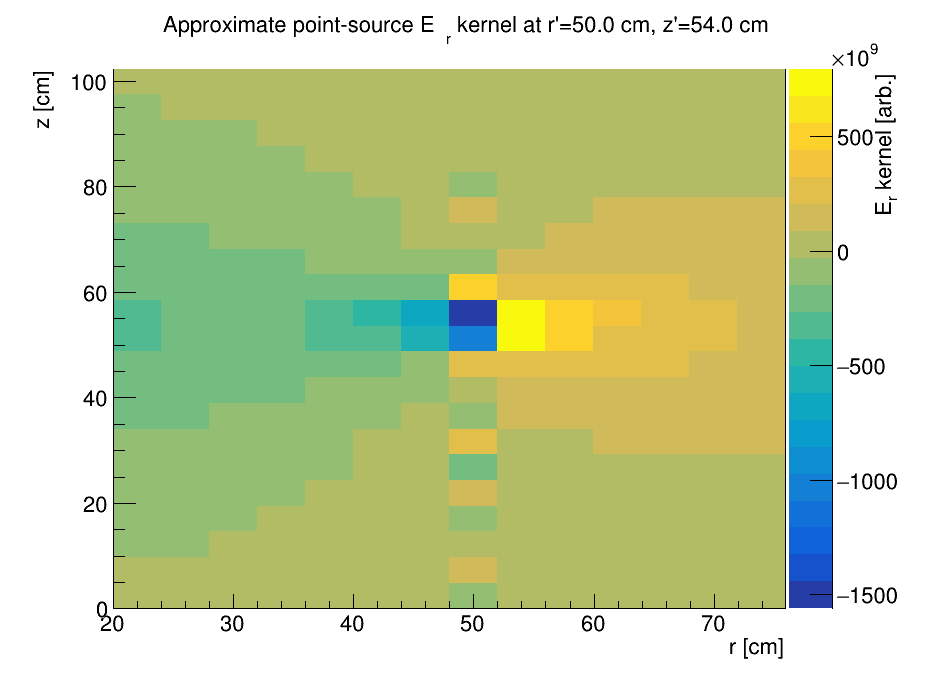

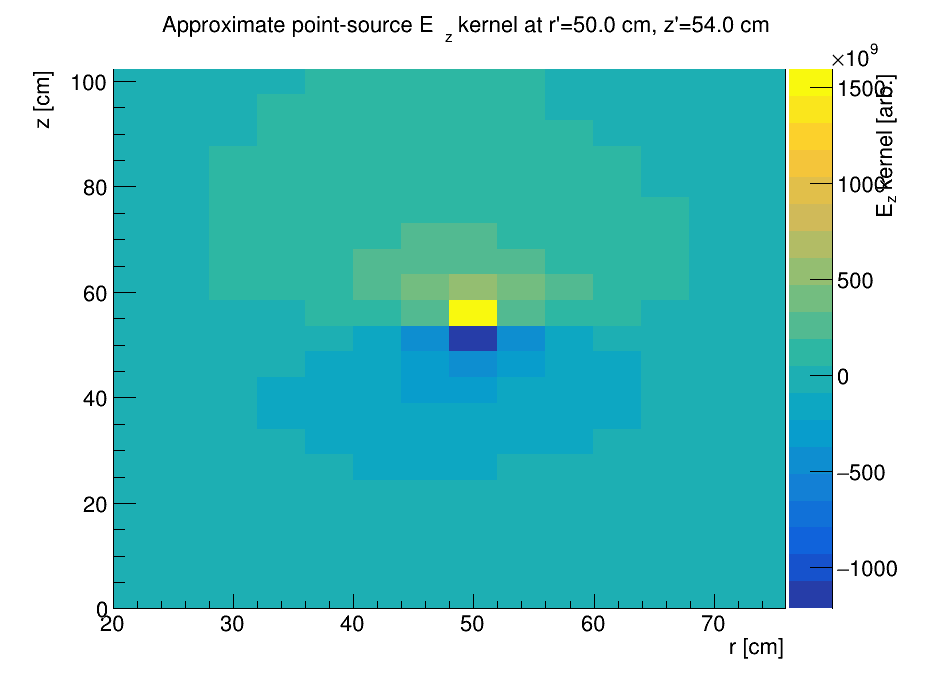

Info in <TCanvas::Print>: png file rossegger3d_qa/qa_Er_point_kernel.png has been created
Info in <TCanvas::Print>: png file rossegger3d_qa/qa_Ez_point_kernel.png has been created


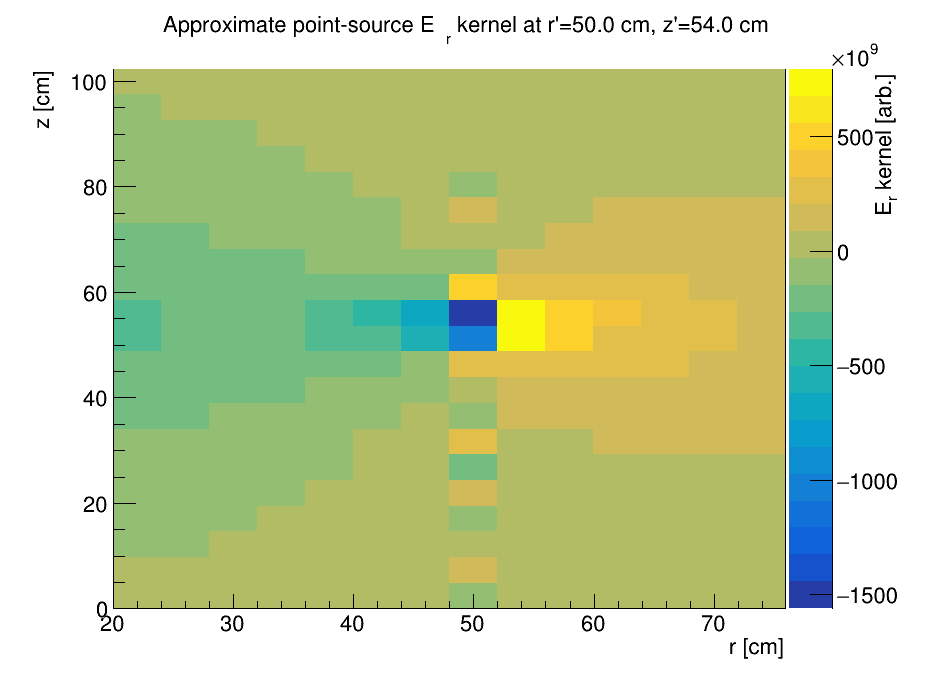

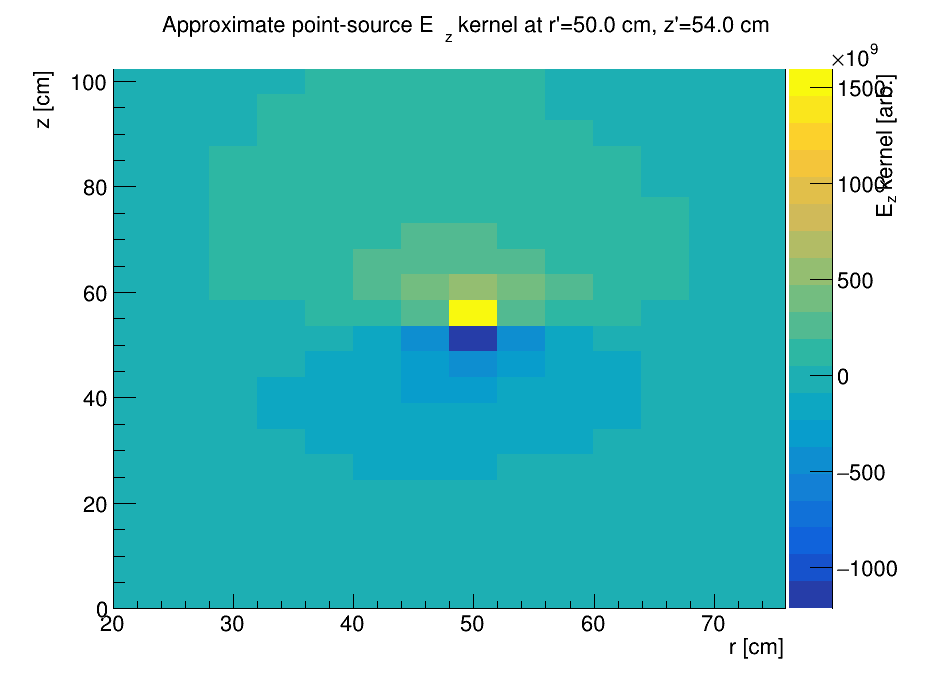

In [29]:
# ============================================================
# QA: approximate point-like source response in r-z plane
# ============================================================

if DO_QA:
    r0_cm = 50.0
    z0_cm = 54.0
    r0 = r0_cm * CM_TO_M
    z0 = z0_cm * CM_TO_M

    Er_kernel = np.zeros((nr_obs, nz_obs))
    Ez_kernel = np.zeros((nr_obs, nz_obs))

    # --- Ez kernel from the optimized Ez representation
    for n, kval in enumerate(k_modes[0][:N_RADIAL_MODES]):
        R_src = radial_basis(kval, 0, r0)
        norm = radial_norms[0][n]

        for iz, zval in enumerate(z_obs):
            dG = d_green_z_dz(kval, zval, z0)
            Ez_kernel[:, iz] += (
                -1.0 / EPSILON_0
                * radial_basis(kval, 0, r_obs)
                * R_src
                * dG
                / norm
            )

    # --- Er kernel from the optimized Er representation
    for il, qval in enumerate(q_modes[:N_LONGITUDINAL_MODES]):
        u, du, v, dv, C = radial_modified_bessel_parts(qval)

        z_factor = np.sin(qval * z_obs) * np.sin(qval * z0)

        dgdr = np.zeros(nr_obs)
        for ir, rval in enumerate(r_obs):
            if rval < r0:
                dgdr[ir] = -du(rval) * v(r0) / C
            elif rval > r0:
                dgdr[ir] = -u(r0) * dv(rval) / C
            else:
                dgdr[ir] = 0.0

        Er_kernel += (
            -2.0 / (EPSILON_0 * L)
            * np.outer(dgdr, z_factor)
        )

    hEr_kernel = make_th2(
        "hErPointKernel",
        f"Approximate point-source E_{{r}} kernel at r'={r0_cm:.1f} cm, z'={z0_cm:.1f} cm",
        Er_kernel,
        100.0 * r_obs_edges,
        100.0 * z_obs_edges,
        "r [cm]",
        "z [cm]",
        "E_{r} kernel [arb.]"
    )
    draw_th2("qa_Er_point_kernel", hEr_kernel)

    hEz_kernel = make_th2(
        "hEzPointKernel",
        f"Approximate point-source E_{{z}} kernel at r'={r0_cm:.1f} cm, z'={z0_cm:.1f} cm",
        Ez_kernel,
        100.0 * r_obs_edges,
        100.0 * z_obs_edges,
        "r [cm]",
        "z [cm]",
        "E_{z} kernel [arb.]"
    )
    draw_th2("qa_Ez_point_kernel", hEz_kernel)

In [19]:
if DO_QA:
    Er0 = np.zeros_like(E_r)
    Ep0 = np.zeros_like(E_r)
    Ez0 = np.zeros_like(E_r)

    for ir, rr in enumerate(r_obs):
        for ip, pp in enumerate(phi_obs):
            for iz, zz in enumerate(z_obs):
                Er0[ir,ip,iz], Ep0[ir,ip,iz], Ez0[ir,ip,iz] = (
                    evaluate_field_point(rr,pp,zz,m_limit=0)
                )

    phi_spread_Er = np.max(np.ptp(Er0, axis=1))
    phi_spread_Ez = np.max(np.ptp(Ez0, axis=1))
    max_Ephi0 = np.max(np.abs(Ep0))

    print("m=0 QA:")
    print("  max phi spread Er =", phi_spread_Er, "V/m")
    print("  max phi spread Ez =", phi_spread_Ez, "V/m")
    print("  max |Ephi|        =", max_Ephi0, "V/m")

# Physical baseline must be axisymmetric to numerical precision.
if AXISYMMETRIC_BASELINE:
    field_scale = max(
        np.max(np.abs(Er0)),
        np.max(np.abs(Ez0)),
        1.0
    )
    rel_phi_spread = max(phi_spread_Er, phi_spread_Ez) / field_scale
    rel_ephi = max_Ephi0 / field_scale

    print("  relative phi spread =", rel_phi_spread)
    print("  relative |Ephi|     =", rel_ephi)

    if rel_phi_spread > 1e-11:
        raise RuntimeError(
            "Axisymmetric baseline has unexpected phi dependence."
        )
    if rel_ephi > 1e-11:
        raise RuntimeError(
            "Axisymmetric baseline has nonzero Ephi."
        )


m=0 QA:
  max phi spread Er = 0.0 V/m
  max phi spread Ez = 0.0 V/m
  max |Ephi|        = 0.0 V/m
  relative phi spread = 0.0
  relative |Ephi|     = 0.0


## 9. Boundary-potential QA

The perturbation potential must vanish at:

- \(r=a\);
- \(r=b\);
- \(z=0\);
- \(z=L\).

This test evaluates the spectral potential directly on the boundaries. The residual should be close to numerical precision apart from mode-truncation and special-function roundoff.

In [20]:
if DO_QA:
    phitest = np.linspace(0,2*np.pi,13,endpoint=False)
    rtest = np.linspace(a,b,17)
    ztest = np.linspace(0,L,17)

    residuals = []

    for pp in phitest:
        for zz in ztest:
            residuals.append(abs(evaluate_field_point(a,pp,zz,return_potential=True)[0]))
            residuals.append(abs(evaluate_field_point(b,pp,zz,return_potential=True)[0]))
        for rr in rtest:
            residuals.append(abs(evaluate_field_point(rr,pp,0.0,return_potential=True)[0]))
            residuals.append(abs(evaluate_field_point(rr,pp,L,return_potential=True)[0]))

    print("Boundary potential QA:")
    print("  max |Phi_boundary| =", max(residuals), "V")

Boundary potential QA:
  max |Phi_boundary| = 3.4677321591649123e-13 V


## 10. Convergence QA

The linked `roswell` repository studies summation runaway and loss of numerical precision in Rossegger-type series. Therefore convergence must be checked rather than assumed.

The next cell scans:

- maximum azimuthal harmonic \(m_{\max}\);
- number of radial modes;
- number of longitudinal modes.

Stable plateaus are expected away from a source boundary. Oscillation or growth at high order indicates precision loss or an unsuitable representation.

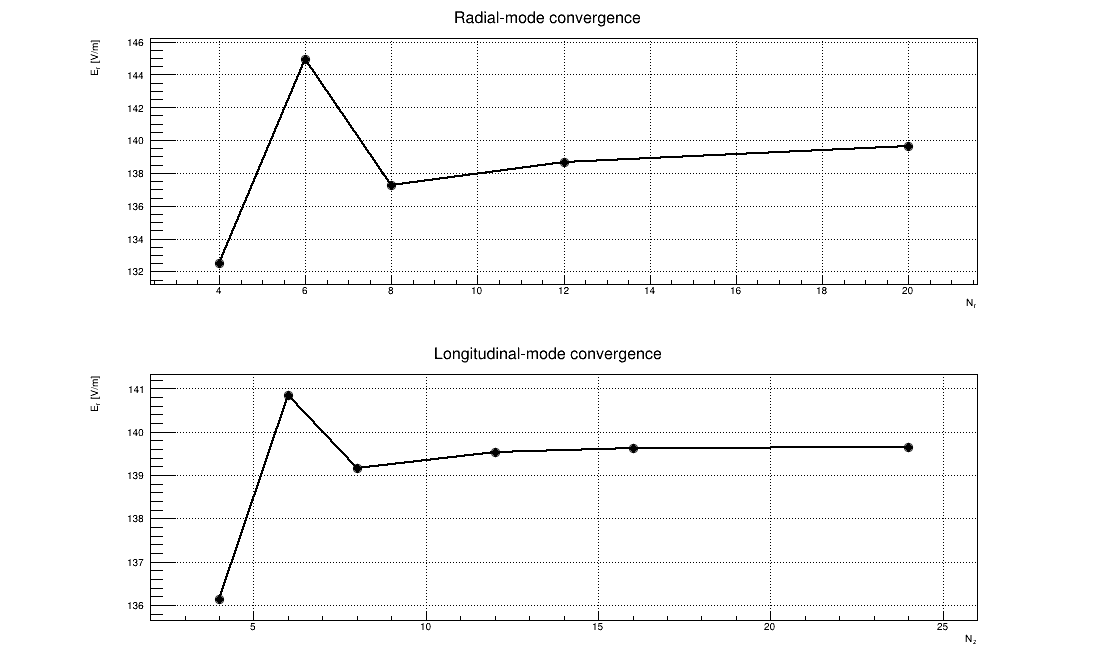

Info in <TCanvas::Print>: png file rossegger3d_qa/qa_convergence.png has been created


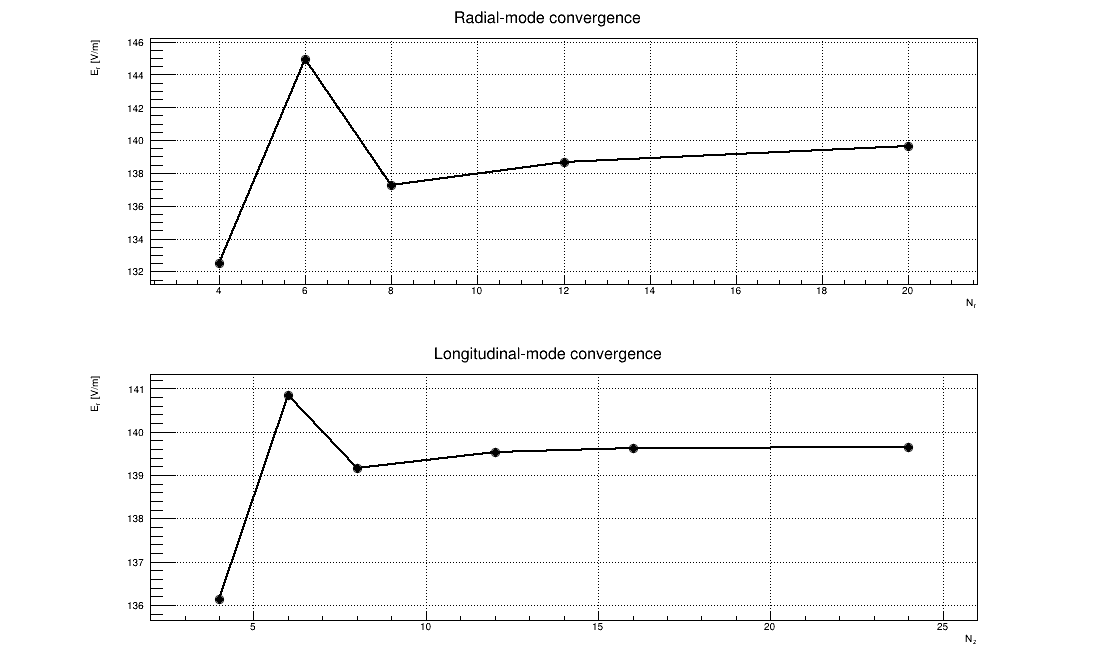

In [21]:
if DO_CONVERGENCE_QA:
    rqa = QA_SOURCE_R_CM*CM_TO_M
    phqa = 0.0
    zqa = QA_SOURCE_Z_CM*CM_TO_M

    nr_values = sorted(set([4,6,8,12,N_RADIAL_MODES]))
    nz_values = sorted(set([4,6,8,12,16,N_LONGITUDINAL_MODES]))
    nr_values = [n for n in nr_values if n<=N_RADIAL_MODES]
    nz_values = [n for n in nz_values if n<=N_LONGITUDINAL_MODES]

    conv_nr = np.array([
        evaluate_field_point(rqa,phqa,zqa,nrad_limit=n)[0]
        for n in nr_values
    ])
    conv_nz = np.array([
        evaluate_field_point(rqa,phqa,zqa,nzmode_limit=n)[0]
        for n in nz_values
    ])

    panels = [
        (nr_values, conv_nr, "Radial-mode convergence", "N_{r}"),
        (nz_values, conv_nz, "Longitudinal-mode convergence", "N_{z}"),
    ]

    if DO_PHI_QA:
        m_values = list(range(0,M_PHI_EFFECTIVE_MAX+1))
        conv_m = np.array([
            evaluate_field_point(rqa,phqa,zqa,m_limit=m)[0]
            for m in m_values
        ])
        panels.insert(
            0, (m_values, conv_m, "Azimuthal convergence", "m_{max}")
        )

    c = root.TCanvas(
        "qa_convergence", "", 1100, 350*len(panels)
    )
    c.Divide(1, len(panels))

    convergence_graphs = []
    for ipad, (x, y, title, xtitle) in enumerate(panels, start=1):
        c.cd(ipad)
        root.gPad.SetGrid()
        root.gPad.SetLeftMargin(0.13)
        root.gPad.SetBottomMargin(0.14)

        g = graph_from_xy(
            x, y, f"gconv{ipad}",
            title, xtitle, "E_{r} [V/m]"
        )
        g.SetMarkerStyle(20)
        g.Draw("ALP")
        qa_objects.append(g)
        convergence_graphs.append(g)

    c.Update()
    png = str(Path(QA_PLOT_DIRECTORY)/"qa_convergence.png")
    c.SaveAs(png)
    display(Image(filename=png))
    qa_canvases.append(c)

## 11. Three-dimensional Gauss-law QA

For a closed cylindrical surface covering the full \(2\pi\) azimuth,

$$
\Phi_E
=
\int E_r(r_2,\phi,z)\,r_2\,d\phi\,dz
-
\int E_r(r_1,\phi,z)\,r_1\,d\phi\,dz
$$

$$
+
\int E_z(r,\phi,z_2)\,r\,dr\,d\phi
-
\int E_z(r,\phi,z_1)\,r\,dr\,d\phi.
$$

There are no azimuthal side faces because the surface wraps through the full \(2\pi\). Gauss's law requires

$$
\epsilon_0\Phi_E=Q_{\rm enclosed}.
$$

This test encloses a selected radial and longitudinal range while integrating over all \(\phi\). It validates the full 3D source normalization. Separate periodicity and rotation tests validate \(E_\phi\).

In [22]:
def gauss_flux_full_phi(r1,r2,z1,z2):
    xg,wg = leggauss(GAUSS_QUADRATURE_ORDER)

    # phi quadrature
    pq = np.pi*(xg+1)
    wp = np.pi*wg

    # z quadrature
    zq = 0.5*(z2-z1)*xg + 0.5*(z2+z1)
    wz = 0.5*(z2-z1)*wg

    # r quadrature
    rq = 0.5*(r2-r1)*xg + 0.5*(r2+r1)
    wr = 0.5*(r2-r1)*wg

    flux = 0.0

    for ip,pp in enumerate(pq):
        for iz,zz in enumerate(zq):
            Er2 = evaluate_field_point(r2,pp,zz)[0]
            Er1 = evaluate_field_point(r1,pp,zz)[0]
            flux += wp[ip]*wz[iz]*(r2*Er2-r1*Er1)

        for ir,rr in enumerate(rq):
            Ez2 = evaluate_field_point(rr,pp,z2)[2]
            Ez1 = evaluate_field_point(rr,pp,z1)[2]
            flux += wp[ip]*wr[ir]*rr*(Ez2-Ez1)

    return flux

if DO_GAUSS_QA:
    ir0 = int(np.argmin(abs(r_src-QA_SOURCE_R_CM*CM_TO_M)))
    iz0 = int(np.argmin(abs(z_src-QA_SOURCE_Z_CM*CM_TO_M)))

    r1 = r_src_edges[max(0,ir0-2)]
    r2 = r_src_edges[min(nr_src,ir0+3)]
    z1 = z_src_edges[max(0,iz0-2)]
    z2 = z_src_edges[min(nz_src,iz0+3)]

    flux = gauss_flux_full_phi(r1,r2,z1,z2)

    rmask = (r_src>=r1)&(r_src<=r2)
    zmask = (z_src>=z1)&(z_src<=z2)
    Qenc = np.sum(Q_cells[rmask,:,:][:,:,zmask])

    ratio = EPSILON_0*flux/Qenc
    print("3D Gauss-law QA:")
    print("  enclosed charge =", Qenc, "C")
    print("  epsilon0*flux/Q =", ratio)

3D Gauss-law QA:
  enclosed charge = 3.99037359717334e-09 C
  epsilon0*flux/Q = 1.0014202206983818


## 12. Optional independent 3D finite-difference cross-check

The spectral solver can be compared with an independent periodic cylindrical finite-difference Poisson solver:

$$
\frac{1}{r}\frac{\partial}{\partial r}
\left(r\frac{\partial\Phi}{\partial r}\right)
+
\frac{1}{r^2}\frac{\partial^2\Phi}{\partial\phi^2}
+
\frac{\partial^2\Phi}{\partial z^2}
=
-\frac{\rho}{\epsilon_0}.
$$

This is computationally more expensive, so it is disabled by default. Enable `DO_3D_FD_CROSSCHECK` after the spectral QA passes.

Expected result: the bulk residual should be small, while the largest differences appear near boundaries and sharp source transitions.

In [23]:
if DO_3D_FD_CROSSCHECK:
    print("3D finite-difference cross-check is enabled.")
    print("Development placeholder: build periodic sparse cylindrical Laplacian here.")
    print("The spectral solver and all earlier QA remain independent of this optional cell.")

## 13. Save the complete 3D maps to ROOT

The output contains:

- `hRho`: \(\rho(r,\phi,z)\) in \(\mathrm{nC/m^3}\);
- `hEr`, `hEphi`, `hEz`: perturbation fields in \(\mathrm{V/m}\);
- grid vectors and metadata;
- QA canvases and graphs.

The field maps are stored as `TH3D` with axes:

1. \(r\) in cm;
2. \(\phi\) in radians;
3. \(z\) in cm.

Garfield uses \(\mathrm{V/cm}\), so divide the stored values by 100 when reading them into the Garfield callback.

In [24]:
def make_th3(name,title,values,xedges,yedges,zedges,ztitle):
    xb = array("d", np.asarray(xedges,dtype=float).tolist())
    yb = array("d", np.asarray(yedges,dtype=float).tolist())
    zb = array("d", np.asarray(zedges,dtype=float).tolist())
    h = root.TH3D(
        name,title,
        len(xb)-1,xb,
        len(yb)-1,yb,
        len(zb)-1,zb
    )
    h.GetXaxis().SetTitle("r [cm]")
    h.GetYaxis().SetTitle("#phi [rad]")
    h.GetZaxis().SetTitle("z [cm]")
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            for k in range(values.shape[2]):
                h.SetBinContent(i+1,j+1,k+1,float(values[i,j,k]))
    h.SetTitle(f"{title};r [cm];#phi [rad];z [cm]")
    return h

if WRITE_ROOT_OUTPUT:
    fout = root.TFile(OUTPUT_ROOT_FILE,"RECREATE")
    if not fout or fout.IsZombie():
        raise OSError(f"Cannot create {OUTPUT_ROOT_FILE}")

    metadata = {
        "solver": "full 3D ordinary-Bessel/Fourier/sine Green function",
        "scope": (
            "axisymmetric m=0 component-optimized Rossegger solver: "
            "modified-Bessel representation for Er and hyperbolic "
            "longitudinal representation for Ez"
        ),
        "geometry_cm": {
            "field_cage_inner": 100*a,
            "field_cage_outer": 100*b,
            "drift_length": 100*L
        },
        "modes": {
            "m_max_configured": M_PHI_MAX,
            "m_max_effective": M_PHI_EFFECTIVE_MAX,
            "n_radial": N_RADIAL_MODES,
            "n_longitudinal": N_LONGITUDINAL_MODES
        },
        "charge": {
            "rho_average_nC_per_m3": RHO_REFERENCE_NC_PER_M3,
            "radial_exponent_alpha": RADIAL_EXPONENT_ALPHA,
            "m1_amplitude": M1_AMPLITUDE,
            "m12_amplitude": M12_AMPLITUDE,
            "k_eff": K_EFF,
            "axisymmetric_baseline": AXISYMMETRIC_BASELINE,
            "phi_qa_enabled": DO_PHI_QA,
            "rossegger_optimized_er": DO_ROSSEGGER_OPTIMIZED_ER,
            "optimized_er_used_for_output": USE_OPTIMIZED_ER_FOR_OUTPUT,
            "rossegger_optimized_ez": DO_ROSSEGGER_OPTIMIZED_EZ,
            "optimized_ez_used_for_output": USE_OPTIMIZED_EZ_FOR_OUTPUT
        },
        "units": {
            "field": "V/m",
            "density": "nC/m^3",
            "r_z_axes": "cm",
            "phi_axis": "rad"
        }
    }
    root.TNamed("metadata_json",json.dumps(metadata,indent=2)).Write()

    hRho = make_th3(
        "hRho","Charge density",
        rho*1e9,
        100*r_src_edges,phi_src_edges,100*z_src_edges,
        "rho [nC/m^3]"
    )
    hEr = make_th3(
        "hEr","Space-charge Er",
        E_r,
        100*r_obs_edges,phi_obs_edges,100*z_obs_edges,
        "Er [V/m]"
    )
    hEphi = None
    if WRITE_EPHI_MAP:
        hEphi = make_th3(
            "hEphi","Space-charge Ephi",
            E_phi,
            100*r_obs_edges,phi_obs_edges,100*z_obs_edges,
            "Ephi [V/m]"
        )
    hEz = make_th3(
        "hEz","Space-charge Ez",
        E_z,
        100*r_obs_edges,phi_obs_edges,100*z_obs_edges,
        "Ez [V/m]"
    )

    hRho.Write()
    hEr.Write()
    if hEphi is not None:
        hEphi.Write()
    hEz.Write()

    qadir = fout.mkdir("QA")
    qadir.cd()
    for obj in qa_objects:
        obj.Write()
    for c in qa_canvases:
        c.Write()

    fout.cd()
    fout.Write()
    fout.Close()
    print("Wrote", OUTPUT_ROOT_FILE)

Wrote sphenix_rossegger3d_field.root


In [26]:
# ============================================================
# Write a separate Garfield-compatible axisymmetric field file
# ============================================================

GARFIELD_COMPATIBLE_ROOT_FILE = (
    "sphenix_rossegger_garfield_field.root"
)

# The present physical baseline must be axisymmetric.
Er_phi_spread = np.max(np.ptp(E_r, axis=1))
Ez_phi_spread = np.max(np.ptp(E_z, axis=1))

field_scale = max(
    np.max(np.abs(E_r)),
    np.max(np.abs(E_z)),
    1.0
)

relative_phi_spread = max(
    Er_phi_spread,
    Ez_phi_spread
) / field_scale

print(
    "Maximum relative phi spread:",
    relative_phi_spread
)

if relative_phi_spread > 1.0e-10:
    raise RuntimeError(
        "The field is not sufficiently axisymmetric "
        "for the Garfield-compatible TH2 output."
    )

# Average over phi. For a true m=0 result, all phi bins are
# already identical.
Er_garfield_rz = np.mean(E_r, axis=1)
Ez_garfield_rz = np.mean(E_z, axis=1)

# Create the separate ROOT file.
f_garfield = root.TFile(
    GARFIELD_COMPATIBLE_ROOT_FILE,
    "RECREATE"
)

if not f_garfield or f_garfield.IsZombie():
    raise OSError(
        f"Could not create {GARFIELD_COMPATIBLE_ROOT_FILE}"
    )

# Reproduce the same directory structure expected by PHGarfield.
qa_directory = f_garfield.mkdir("QA")
qa_directory.cd()

hErDefault = make_th2(
    "hErDefault",
    "Axisymmetric space-charge E_{r}",
    Er_garfield_rz,
    100.0 * r_obs_edges,
    100.0 * z_obs_edges,
    "r [cm]",
    "|z| [cm]",
    "E_{r} [V/m]"
)

hEzDefault = make_th2(
    "hEzDefault",
    "Axisymmetric local space-charge E_{z}",
    Ez_garfield_rz,
    100.0 * r_obs_edges,
    100.0 * z_obs_edges,
    "r [cm]",
    "|z| [cm]",
    "E_{z}^{local} [V/m]"
)

hErDefault.Write()
hEzDefault.Write()

# Add compact metadata without changing the expected map structure.
f_garfield.cd()

garfield_metadata = {
    "format": "PHGarfield axisymmetric field correction",
    "histograms": {
        "Er": "QA/hErDefault",
        "Ez": "QA/hEzDefault"
    },
    "axes": {
        "x": "r [cm]",
        "y": "local |z| [cm]"
    },
    "field_units": "V/m",
    "coordinate_convention": {
        "Er": "positive toward increasing radius",
        "Ez": (
            "local one-side component, positive toward "
            "increasing |z|"
        )
    },
    "axisymmetric": True,
    "k_eff_applied_in_notebook": K_EFF,
    "optimized_Er": bool(
        DO_ROSSEGGER_OPTIMIZED_ER
        and USE_OPTIMIZED_ER_FOR_OUTPUT
    ),
    "optimized_Ez": bool(
        DO_ROSSEGGER_OPTIMIZED_EZ
        and USE_OPTIMIZED_EZ_FOR_OUTPUT
    )
}

root.TNamed(
    "metadata_json",
    json.dumps(
        garfield_metadata,
        indent=2
    )
).Write()

f_garfield.Write()
f_garfield.Close()

print(
    "Wrote Garfield-compatible field file:",
    GARFIELD_COMPATIBLE_ROOT_FILE
)

Maximum relative phi spread: 0.0
Wrote Garfield-compatible field file: sphenix_rossegger_garfield_field.root


## 14. ROOT readback QA

The verification cell reopens the file and checks:

- the file is readable;
- all four 3D histograms exist;
- bin counts match the source and observation grids;
- selected field bins reproduce the in-memory arrays;
- metadata are valid JSON.

This catches axis-order mistakes and incomplete writes before the map is used in Garfield.

In [25]:
if VERIFY_ROOT_OUTPUT and WRITE_ROOT_OUTPUT:
    f = root.TFile.Open(OUTPUT_ROOT_FILE,"READ")
    if not f or f.IsZombie():
        raise OSError("ROOT readback failed.")

    hr = f.Get("hRho")
    her = f.Get("hEr")
    hep = f.Get("hEphi") if WRITE_EPHI_MAP else None
    hez = f.Get("hEz")
    meta = f.Get("metadata_json")

    required_objects = [("hRho",hr),("hEr",her),("hEz",hez),("metadata_json",meta)]
    if WRITE_EPHI_MAP:
        required_objects.append(("hEphi",hep))
    for name,obj in required_objects:
        if obj is None:
            raise RuntimeError(f"Missing {name}")

    assert (her.GetNbinsX(),her.GetNbinsY(),her.GetNbinsZ()) == (
        nr_obs,nphi_obs,nz_obs
    )

    probes = [
        (0,0,0),
        (nr_obs//2,nphi_obs//2,nz_obs//2),
        (nr_obs-1,nphi_obs-1,nz_obs-1)
    ]

    for ir,ip,iz in probes:
        assert np.isclose(her.GetBinContent(ir+1,ip+1,iz+1),E_r[ir,ip,iz])
        if WRITE_EPHI_MAP:
            assert np.isclose(hep.GetBinContent(ir+1,ip+1,iz+1),E_phi[ir,ip,iz])
        assert np.isclose(hez.GetBinContent(ir+1,ip+1,iz+1),E_z[ir,ip,iz])

    metadata_read = json.loads(meta.GetTitle())
    print("ROOT readback PASSED")
    print(json.dumps(metadata_read,indent=2))
    f.Close()

ROOT readback PASSED
{
  "solver": "full 3D ordinary-Bessel/Fourier/sine Green function",
  "scope": "axisymmetric m=0 component-optimized Rossegger solver: modified-Bessel representation for Er and hyperbolic longitudinal representation for Ez",
  "geometry_cm": {
    "field_cage_inner": 20.0,
    "field_cage_outer": 75.911,
    "drift_length": 102.325
  },
  "modes": {
    "m_max_configured": 6,
    "m_max_effective": 0,
    "n_radial": 20,
    "n_longitudinal": 24
  },
  "charge": {
    "rho_average_nC_per_m3": 20.0,
    "radial_exponent_alpha": 1.0,
    "m1_amplitude": 0.0,
    "m12_amplitude": 0.0,
    "k_eff": 1.0,
    "axisymmetric_baseline": true,
    "phi_qa_enabled": false,
    "rossegger_optimized_er": true,
    "optimized_er_used_for_output": true,
    "rossegger_optimized_ez": true,
    "optimized_ez_used_for_output": true
  },
  "units": {
    "field": "V/m",
    "density": "nC/m^3",
    "r_z_axes": "cm",
    "phi_axis": "rad"
  }
}


## 15. Interpretation and remaining scope

For the present axisymmetric \(m=0\) problem, the production electric field now uses Rossegger's component-specific representations:

- \(E_r\): modified-Bessel radial Green function with a longitudinal sine-mode sum;
- \(E_z\): ordinary-Bessel radial eigenmode sum with the longitudinal Green function retained in hyperbolic form;
- \(E_\phi=0\): exact under cylindrical symmetry.

This is now aligned with the component choices emphasized in Rossegger's thesis and the sPHENIX implementation slides for the axisymmetric case.

The remaining limitations do not affect the present \(m=0\) baseline:

1. the convergence-extraction formulas of Section 5.1.4 are not required unless observation points approach point-like sources or extremely sharp voxel boundaries;
2. the imaginary-order modified-Bessel representation for \(E_\phi\) is unnecessary while the source is uniform in \(\phi\);
3. a final independent finite-difference comparison should still be run at the production mode counts.

For production, retain the convergence and representation-residual QA and increase mode counts until the field changes are below the required correction precision.

## References

- Stefan Rossegger, *Simulation and Calibration of the ALICE Time-Projection Chamber including innovative Space Charge Calculations*, Chapter 5 and Appendix A.
- T. K. Hemmick, *Space Charge in the sPHENIX TPC / Lost in Space*.
- `rccorliss/roswell`, Python studies of summation runaway, Bessel precision, potential, and \(E_z\) behavior in Rossegger-type expansions.